

# **Engineering Statistics and Probability**
## **Computer Assignment 5**
---

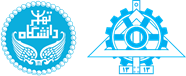

[**School of Electrical and Computer Engineering**, **College of Engineering**, **University of Tehran**](https://ece.ut.ac.ir/)

**Instructors:** Dr. Bahrak, Dr. Vahhabi

**Designers:** [Artin Tavassoli](mailto:artin.tavassoli2@gmail.com), [Mohammad Erfan Danaee](mailto:medanaee@gmail.com)

## **Topic:** Sum of Random Variables, Conditional Distribution, Covariance, and Functions of Two Random Variables

### **Submission Date:**

---

### ℹ️ Student information
+ First name: MohammadHossein
+ Last Name: kabiri
+ SID: 810103496

---

### We will use the following R packages:

*   [`dplyr`](https://cran.r-project.org/web/packages/dplyr/vignettes/dplyr.html): A popular and easy-to-use package for data manipulation in R. (for Qestion 2)
*   [`ggplot2`](https://ggplot2.tidyverse.org/): A powerful package for creating visualizations in R.
*   [`magrittr`](https://magrittr.tidyverse.org) : An package that introduces the pipe operator (%>%) to make code more readable by chaining

+ ⚠️ **Remove comment lines on first run.**


In [52]:
# install.packages("magrittr")
# install.packages("dplyr")
# install.packages("ggplot2")
library(magrittr)
library(dplyr)
library(ggplot2)
set.seed(42)
options(repr.plot.width = 15, repr.plot.height = 6)

# Question 1 (25 points🎯)
## Sum of RVs and function of two RVs ⭐

A company wants to obtain a distribution of the loss it will incur at the end of the upcoming week.

Suppose a company is losing money due to product returns. The number of products of type `a` and `b` returned to the company each day is exponentially distributed and independent of each other, and the company loses 1\$ for each product returned.
Let $X_i$ number of products of type `a` and $Y_i$ number of products of type `b` be returned on day i.

 $$X_i , Y_i \sim Exp(λ = 0.01)$$

### 0. Complete the following two functions to plot the histogram and PDF of the data. (5 points🎯)

+ Note: You can use `geom_density` to plot the PDF.

In [53]:
library(ggplot2)

plot_hist <- function(data, bins = 30, fill_color = "skyblue", line_color = "white") {
  ggplot(data.frame(x = data), aes(x = x)) +
    geom_histogram(
      bins = bins,
      fill = fill_color,
      color = line_color
    ) +
    labs(
      title = "Histogram of Data",
      x = "Value",
      y = "Frequency"
    ) +
    theme_minimal()
}

plot_pdf <- function(data, line_color = "blue", fill_color = "lightblue", alpha = 0.5) {
  ggplot(data.frame(x = data), aes(x = x)) +
    geom_density(
      color = line_color,
      fill = fill_color,
      alpha = alpha
    ) +
    labs(
      title = "Probability Density Function",
      x = "Value",
      y = "Density"
    ) +
    theme_minimal()
}


### 1. Write down the company's loss due to the return of product A after one week. Let's assume this value is equal to $D$. (1 points🎯)

### 2. By generating 100,000 samples of the loss each day caused by product a, obtain 100,000 samples of the $D$. Then plot its PDF and histogram. (2 points🎯)



🔴 **TO DO**

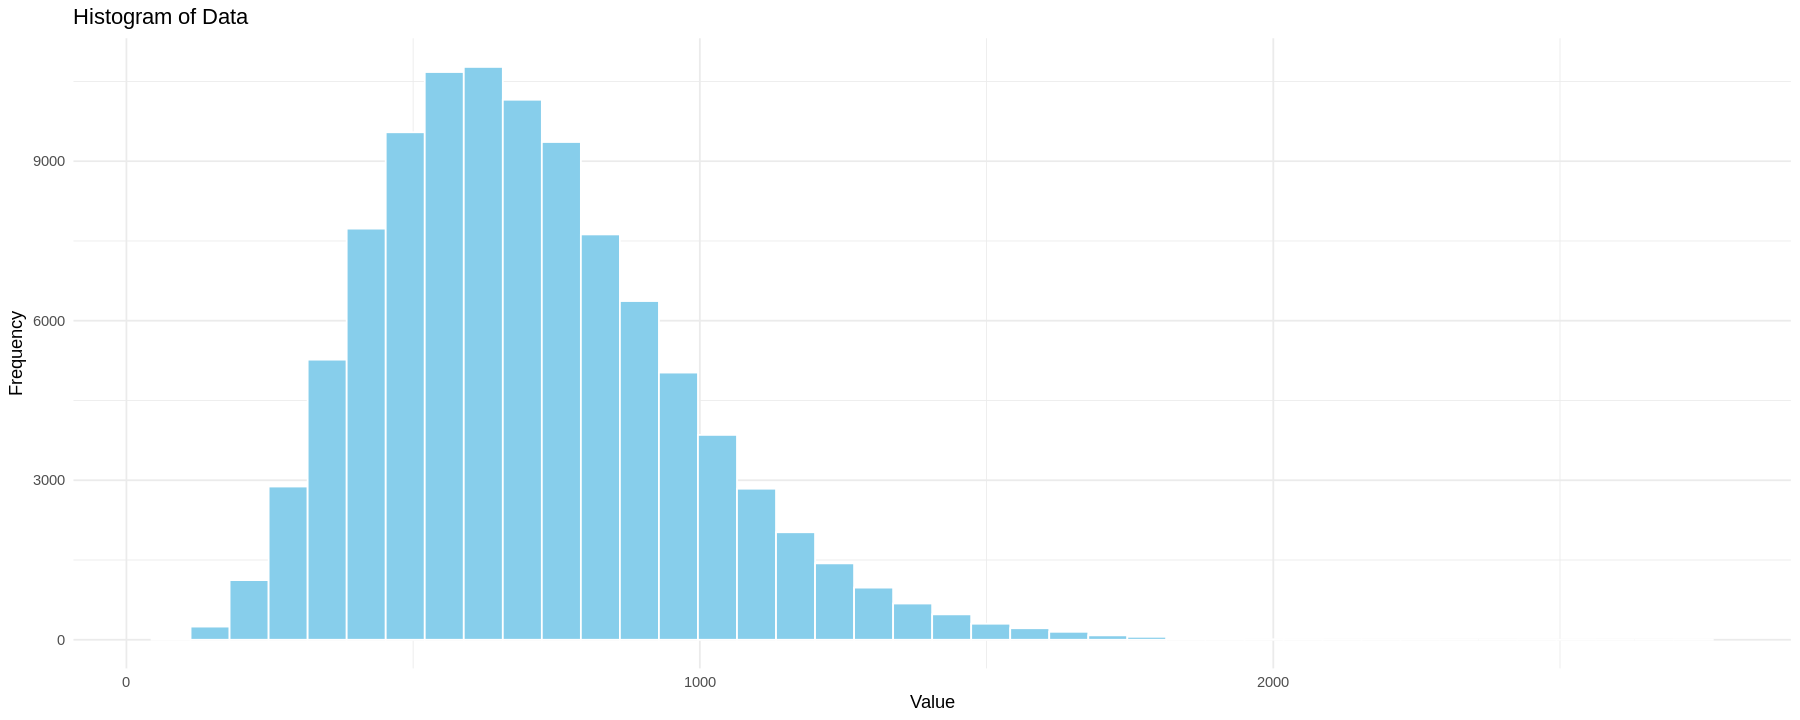

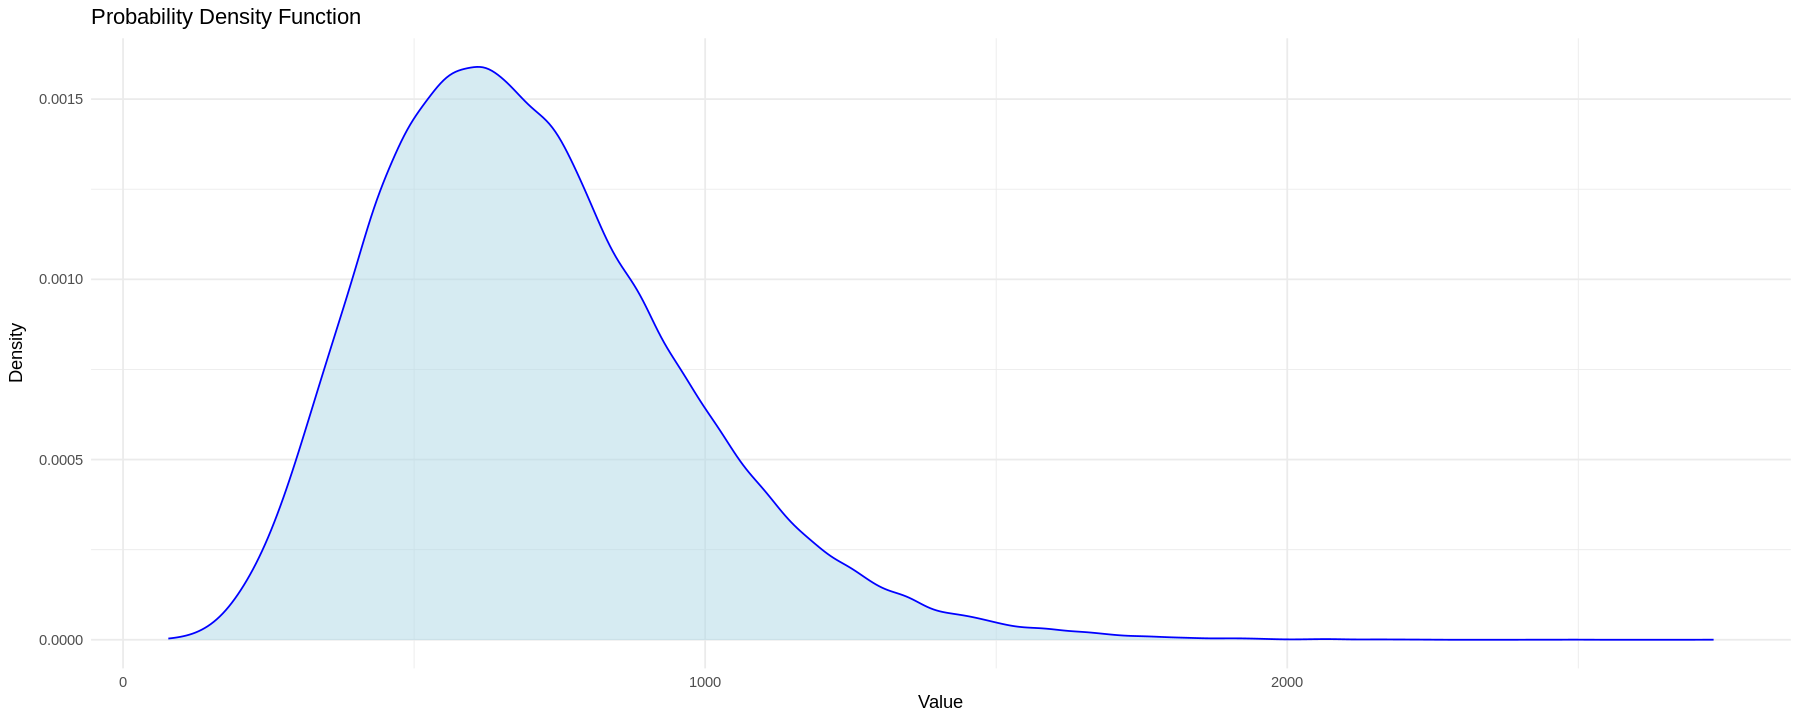

In [54]:
set.seed(123)

# number of simulations
n <- 100000

lambda <- 0.01

# simulate 7 days of losses for each sample
daily_loss <- matrix(rexp(7 * n, rate = lambda), nrow = n, ncol = 7)

# weekly loss D = sum of 7 days
D <- rowSums(daily_loss)

# Plot histogram
plot_hist(D, bins = 40)

# Plot PDF
plot_pdf(D)


### 3. Calculate the mean and variance of the resulting distribution. (1 points🎯)

In [55]:
lambda <- 0.01
mean_D <- 7 * (1/lambda)
var_D  <- 7 * (1/lambda^2)

mean_D
var_D


[1] 700

[1] 70000

The total loss of the company after `n` days is the sum of `n` identical and independent exponential variables.
This sum has a distribution called the [**gamma distribution**](https://en.wikipedia.org/wiki/Gamma_distribution)

### 4. By studying this distribution, obtain the gamma distribution parameters for D and plot it's PDF. (2 points🎯)

🔴 **TO DO**

In [56]:
plot_pdf_theory <- function(x, y,
                    line_color = "blue",
                    line_size = 1,
                    title = "Plot",
                    xlab = "x",
                    ylab = "y") {
  ggplot(data.frame(x, y), aes(x, y)) +
    geom_line(color = line_color, size = line_size) +
    theme_minimal() +
    labs(title = title, x = xlab, y = ylab)
}

In [57]:
library(ggplot2)

lambda <- 0.01
shape <- 7

# x-range for plotting
x_vals <- seq(0, 3000, length.out = 1000)

# theoretical gamma pdf
pdf_vals <- dgamma(x_vals, shape = shape, rate = lambda)

### 5. Calculate the mean and variance theoretically and compare with section 3. (1 points🎯)

In [58]:
# ---- Parameters ----
lambda <- 0.01
shape <- 7   # number of days

# ---- Theoretical mean & variance ----
mean_theory <- shape / lambda
var_theory  <- shape / (lambda^2)

mean_theory
var_theory


# ---- Simulation (like before) ----
set.seed(123)
n <- 100000
daily_loss <- matrix(rexp(7 * n, rate = lambda), nrow = n)
D <- rowSums(daily_loss)

mean_sim <- mean(D)
var_sim  <- var(D)

mean_sim
var_sim


# ---- Print comparison ----
cat("Theoretical Mean =", mean_theory, "\n")
cat("Simulated Mean   =", mean_sim, "\n\n")

cat("Theoretical Variance =", var_theory, "\n")
cat("Simulated Variance   =", var_sim, "\n")


[1] 700

[1] 70000

[1] 699.8392

[1] 70012.91

Theoretical Mean = 700 
Simulated Mean   = 699.8392 

Theoretical Variance = 70000 
Simulated Variance   = 70012.91 


🔴 **TO DO**

Now suppose the company wants to know what percentage of the company's loss after 7 days is related to product a.

### 6. Write down this ratio. plot 100,000 samples of this ratio by generating random samples of the company's losses. Also calculate the mean and variance of the data. (2 points🎯)

This new distribution is called the [**beta distribution**](https://en.wikipedia.org/wiki/Beta_distribution).

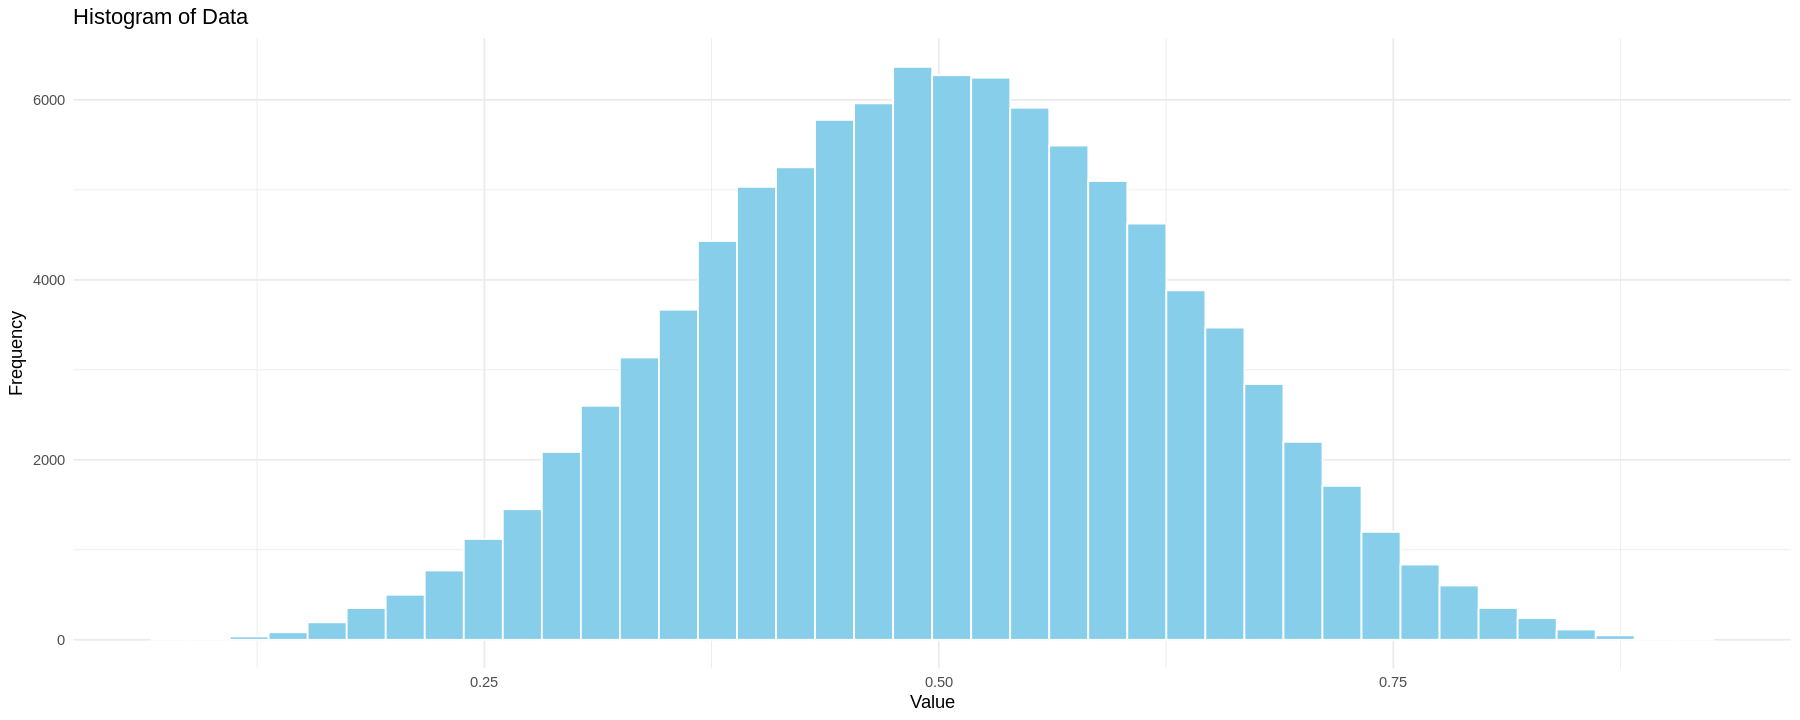

[1] 0.5000351

[1] 0.01671999

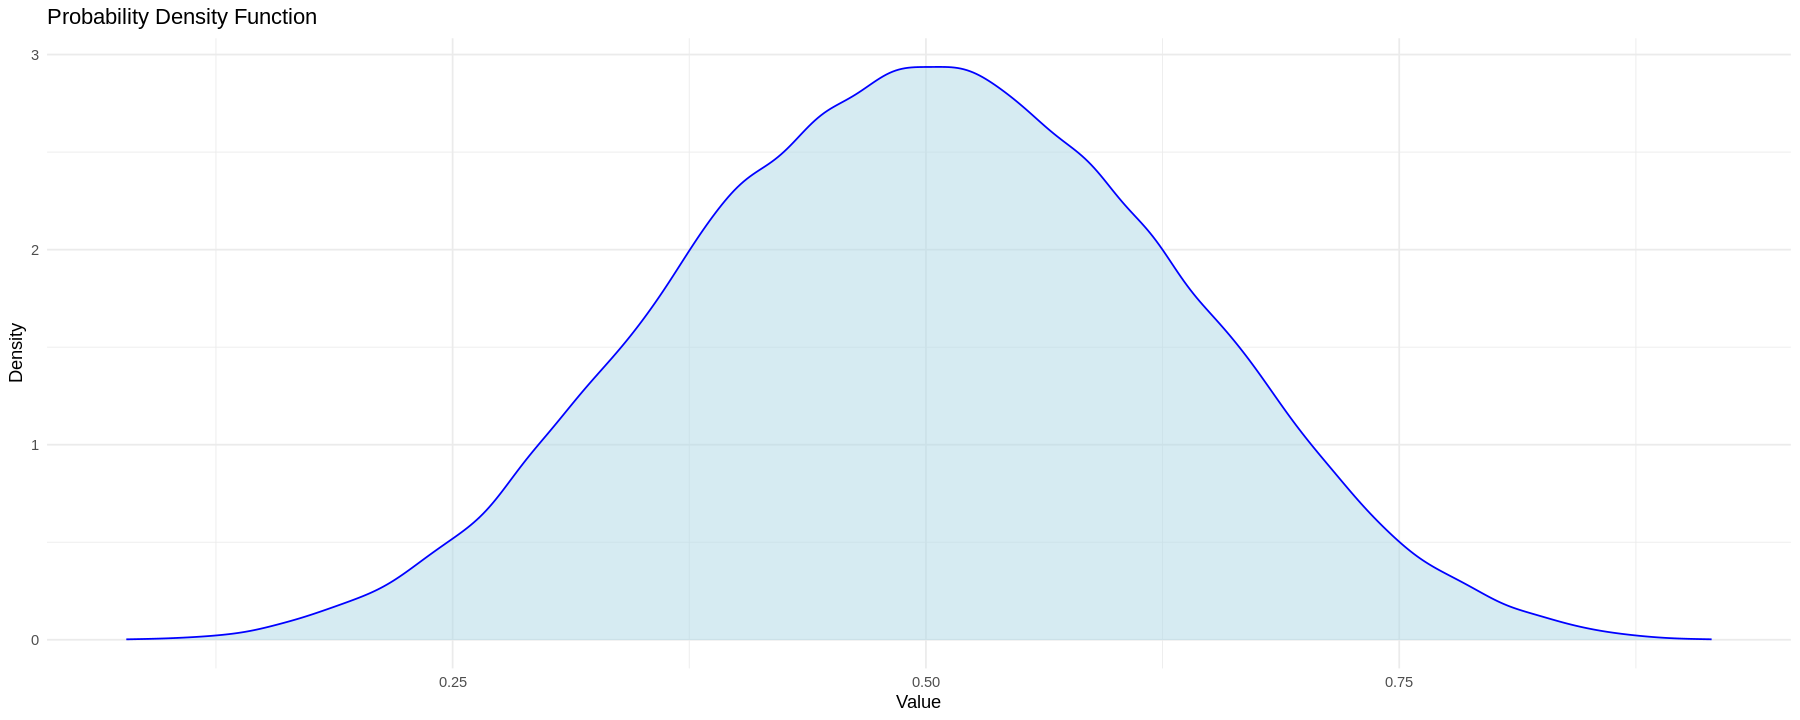

In [59]:
library(ggplot2)

set.seed(123)

n <- 100000
lambda <- 0.01
days <- 7

# simulate losses
A_loss <- matrix(rexp(n * days, rate = lambda), nrow = n)
B_loss <- matrix(rexp(n * days, rate = lambda), nrow = n)

D_A <- rowSums(A_loss)
D_B <- rowSums(B_loss)

# ratio
R <- D_A / (D_A + D_B)

# histogram
plot_hist(R, bins = 40)

# pdf estimate
plot_pdf(R)

# mean & variance
mean_R <- mean(R)
var_R  <- var(R)

mean_R
var_R


### 7. By studying this distribution, calculate its parameters, then theoretically estimate its mean and variance and compare it with Section 6. (5 points🎯)

🔴 **TO DO**

In [60]:
lambda <- 0.01
alpha <- 7
beta  <- 7

# theoretical mean & variance
mean_theory_R <- alpha / (alpha + beta)
var_theory_R  <- (alpha * beta) / ((alpha + beta)^2 * (alpha + beta + 1))

mean_theory_R
var_theory_R


# ---- simulation again ----
set.seed(123)

n <- 100000
days <- 7

A_loss <- matrix(rexp(n * days, rate = lambda), nrow = n)
B_loss <- matrix(rexp(n * days, rate = lambda), nrow = n)

D_A <- rowSums(A_loss)
D_B <- rowSums(B_loss)

R <- D_A / (D_A + D_B)

mean_sim_R <- mean(R)
var_sim_R  <- var(R)

mean_sim_R
var_sim_R


# print comparison
cat("Theoretical Mean =", mean_theory_R, "\n")
cat("Simulated Mean   =", mean_sim_R, "\n\n")

cat("Theoretical Variance =", var_theory_R, "\n")
cat("Simulated Variance   =", var_sim_R, "\n")


[1] 0.5

[1] 0.01666667

[1] 0.5000351

[1] 0.01671999

Theoretical Mean = 0.5 
Simulated Mean   = 0.5000351 

Theoretical Variance = 0.01666667 
Simulated Variance   = 0.01671999 


### 8. Plot the PDF graph of the resulting beta distribution and compare it with the histogram in Section 6. (2 points🎯)

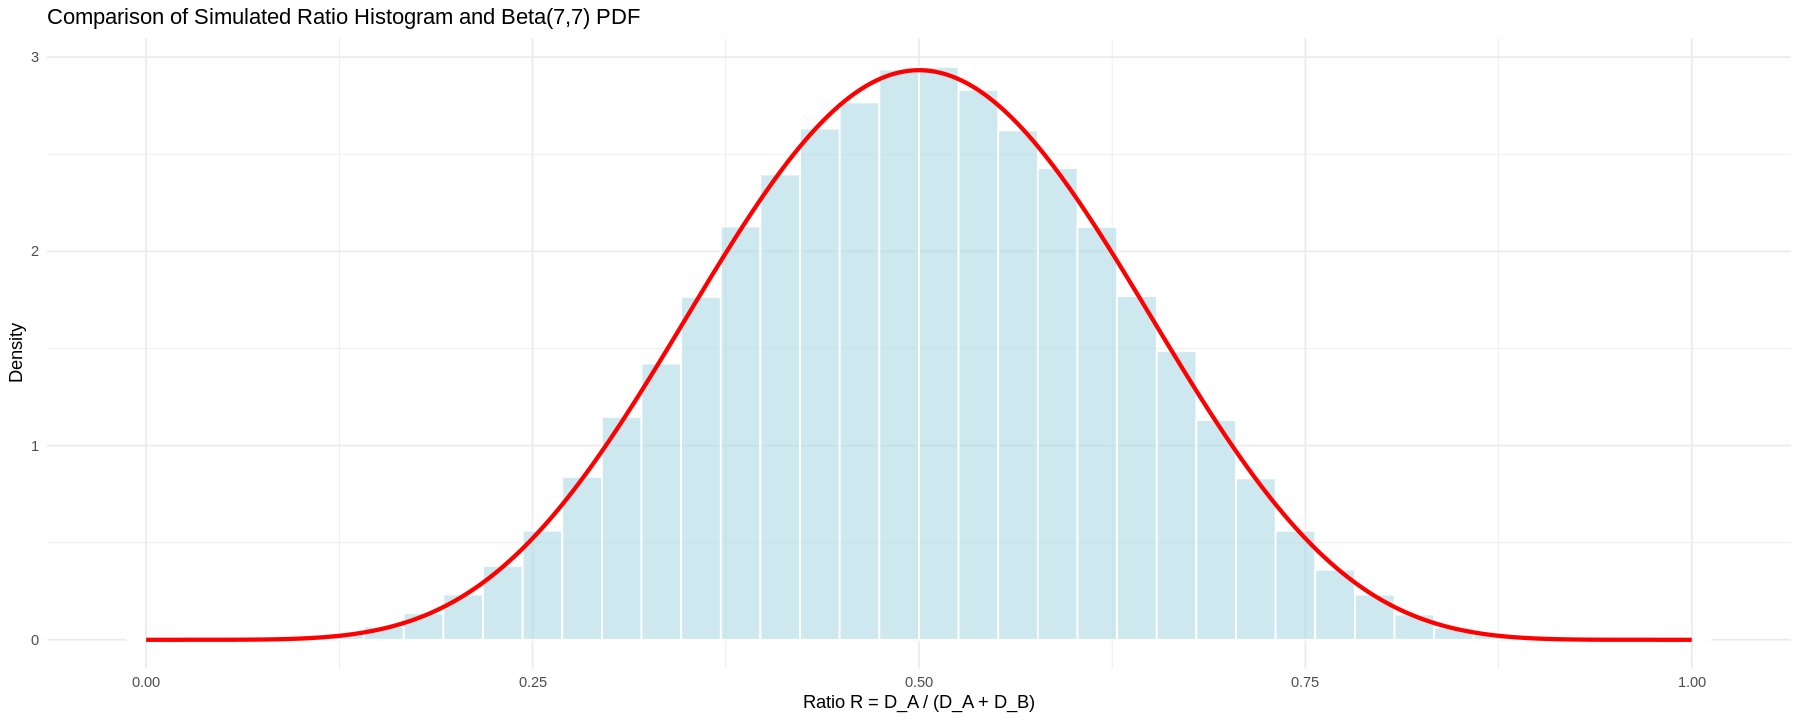

In [61]:
library(ggplot2)

# parameters
alpha <- 7
beta  <- 7

# x-axis values for theoretical pdf
x_vals <- seq(0, 1, length.out = 1000)

# beta pdf
pdf_vals <- dbeta(x_vals, shape1 = alpha, shape2 = beta)

# data frame
df_pdf <- data.frame(x = x_vals, y = pdf_vals)
df_R   <- data.frame(R = R)

# plot histogram + theoretical pdf
ggplot(df_R, aes(x = R)) +
  geom_histogram(aes(y = ..density..),
                 bins = 40,
                 fill = "lightblue",
                 color = "white",
                 alpha = 0.6) +
  geom_line(data = df_pdf,
            aes(x = x, y = y),
            color = "red",
            size = 1.2) +
  theme_minimal() +
  labs(
    title = "Comparison of Simulated Ratio Histogram and Beta(7,7) PDF",
    x = "Ratio R = D_A / (D_A + D_B)",
    y = "Density"
  )


### 9. Now suppose the company wants to calculate the same ratio for a day instead of a week. Re-simulate this ratio. (2 points🎯)
### 10. What distribution does the resulting distribution resemble? Verify this with theoretical calculations. (2 points🎯)

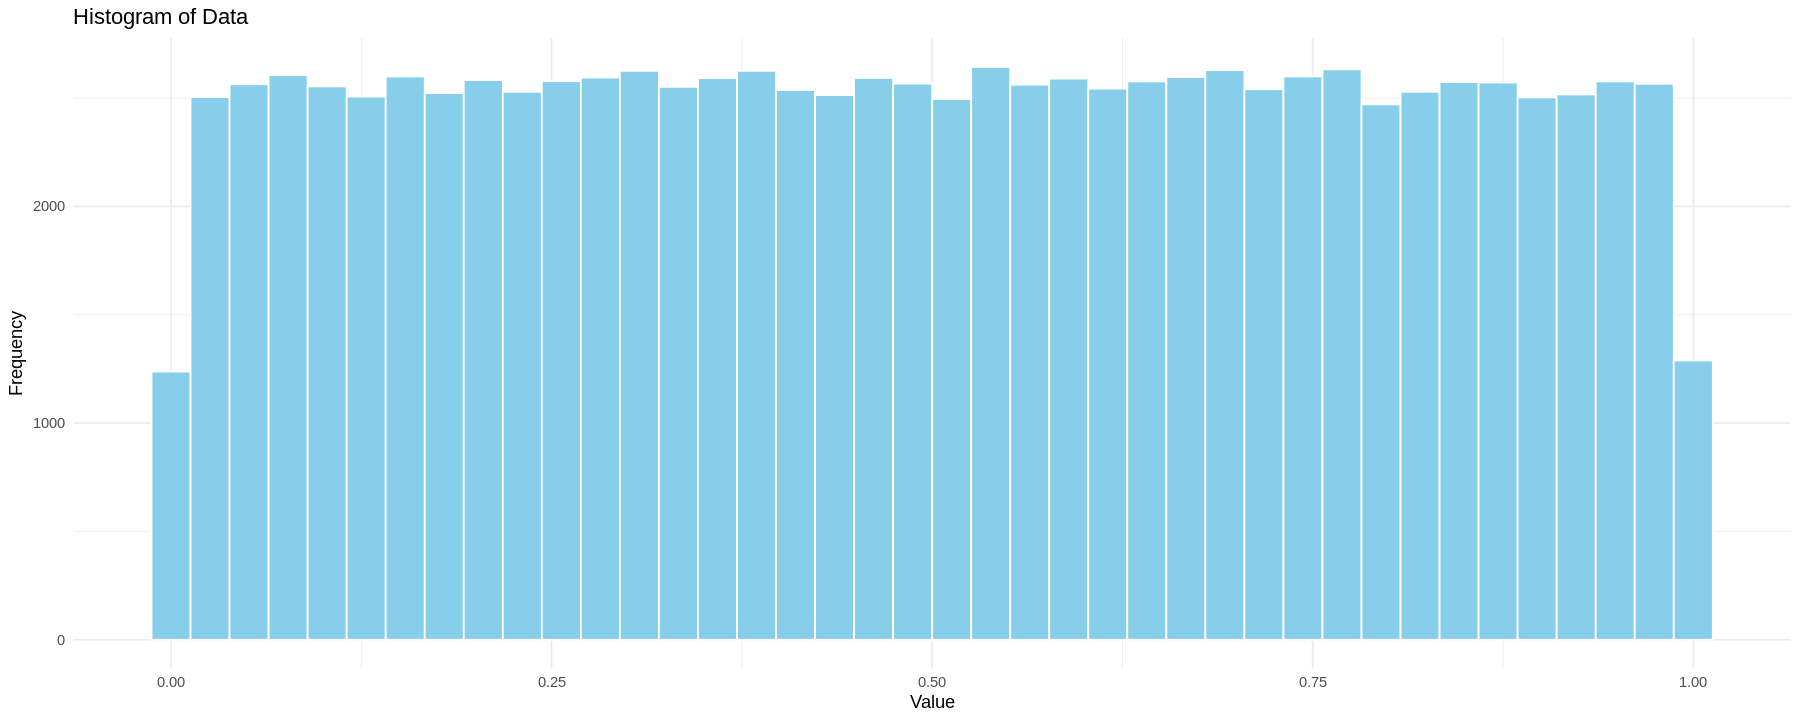

[1] 0.5001596

[1] 0.082975

Theoretical Mean = 0.5 
Simulated Mean   = 0.5001596 

Theoretical Variance = 0.08333333 
Simulated Variance   = 0.082975 


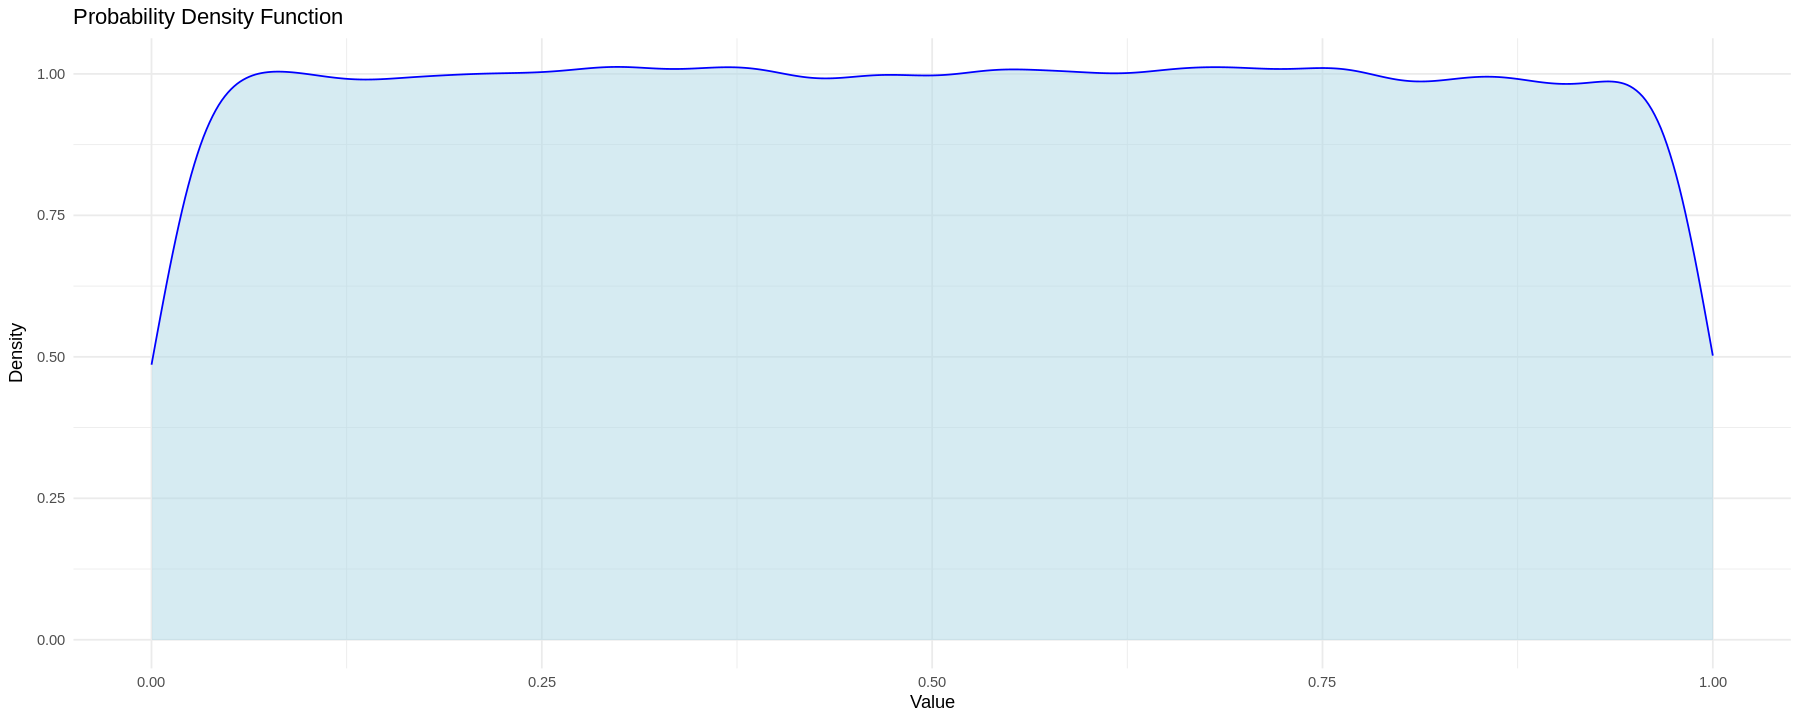

In [62]:
set.seed(123)

n <- 100000
lambda <- 0.01

# simulate daily losses
X_day <- rexp(n, rate = lambda)
Y_day <- rexp(n, rate = lambda)

# daily ratio
R_daily <- X_day / (X_day + Y_day)

# plot histogram
plot_hist(R_daily, bins = 40)

# plot PDF estimate
plot_pdf(R_daily)

# mean & variance
mean_daily <- mean(R_daily)
var_daily  <- var(R_daily)

mean_daily
var_daily
# Theoretical values
mean_theory_daily <- 0.5
var_theory_daily  <- 1/12

cat("Theoretical Mean =", mean_theory_daily, "\n")
cat("Simulated Mean   =", mean_daily, "\n\n")

cat("Theoretical Variance =", var_theory_daily, "\n")
cat("Simulated Variance   =", var_daily, "\n")


🔴 **TO DO**

# Question 2 (25 points🎯)
## Covariance 🌡️

We will use the built-in **airquality** dataset in R, which contains weather data for New York in 1970.

We will focus on the **Day**, **Month**, and **Temp** columns. To represent the progression of the year, we will define a new variable called **Day Number**, which indicates the number of days passed since the beginning of the year.


## Familiarize With Dataset 🌦️ (7.5 points🎯)

### 1. Plot the temperature (**Temp**) against the **Day Number**. This will help you become familiar with the dataset and observe the general trend of temperature throughout the year.

In [63]:
head(airquality)


,Ozone,Solar.R,Wind,Temp,Month,Day,DayNumber
,<int>,<int>,<dbl>,<int>,<int>,<int>,<dbl>
1,41,190,7.4,67,5,1,1
2,36,118,8.0,72,5,2,2
3,12,149,12.6,74,5,3,3
4,18,313,11.5,62,5,4,4
5,NA,NA,14.3,56,5,5,5
6,28,NA,14.9,66,5,6,6


‍

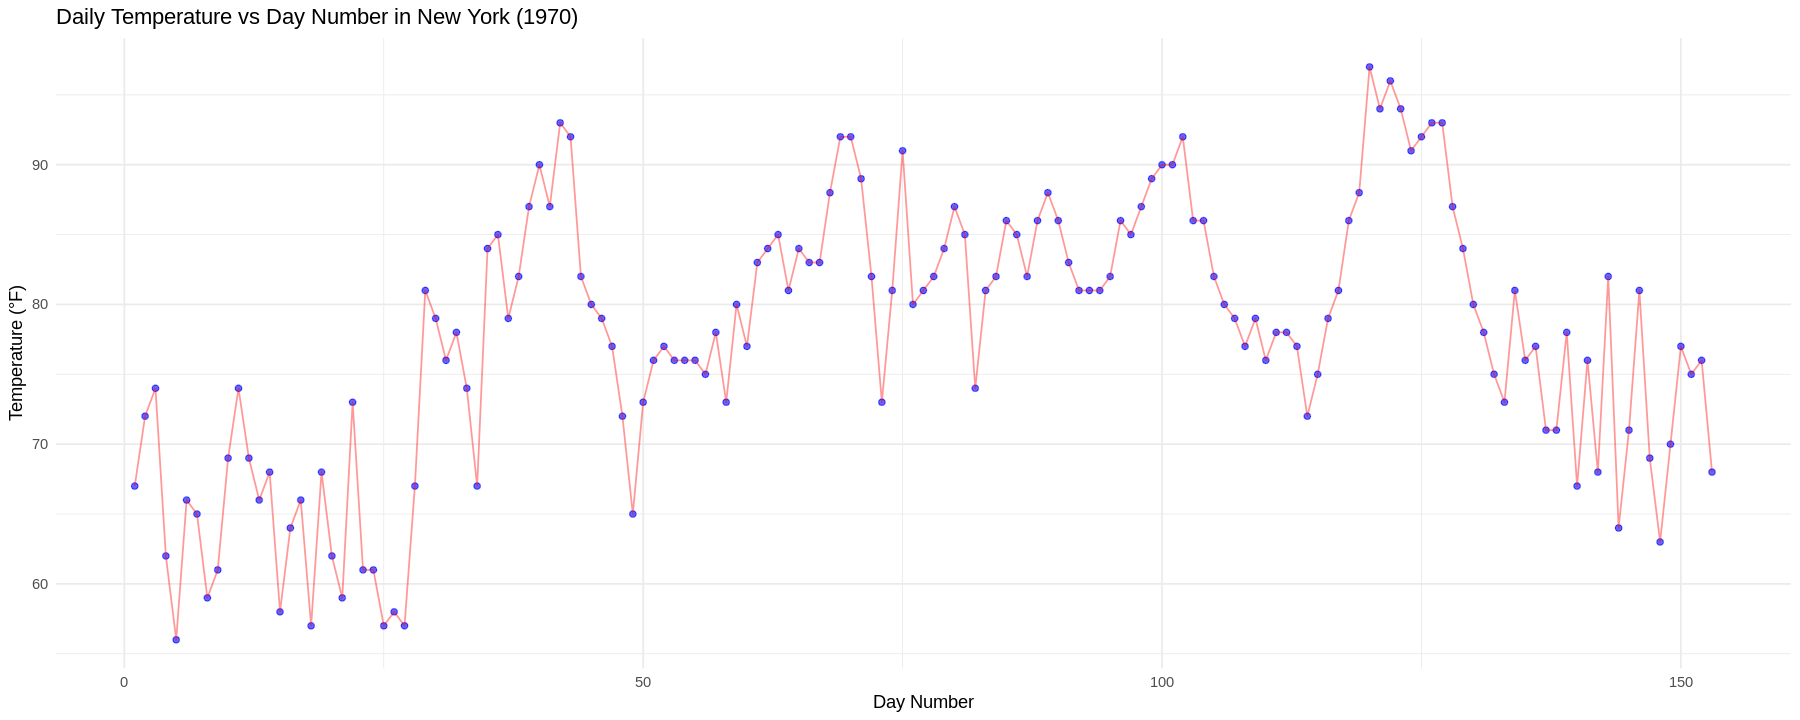

In [64]:
library(ggplot2)
library(dplyr)

# load dataset
data("airquality")

# create Day Number (number of days since beginning of year)
airquality <- airquality %>%
  mutate(DayNumber = case_when(
    Month == 5 ~ Day,
    Month == 6 ~ 31 + Day,
    Month == 7 ~ 31 + 30 + Day,
    Month == 8 ~ 31 + 30 + 31 + Day,
    Month == 9 ~ 31 + 30 + 31 + 31 + Day
  ))

# plot Temp vs DayNumber
ggplot(airquality, aes(x = DayNumber, y = Temp)) +
  geom_point(color = "blue", alpha = 0.6) +
  geom_line(color = "red", alpha = 0.4) +
  theme_minimal() +
  labs(
    title = "Daily Temperature vs Day Number in New York (1970)",
    x = "Day Number",
    y = "Temperature (°F)"
  )


## Correlation Function 🧙 (7.5 points🎯)

### 2. Write a function called `Calculate_Correlation` that takes two vectors, X and Y, as input and returns their correlation. You should implement the correlation calculation yourself and **not** use pre-built correlation functions from R packages.

In [65]:
Calculate_Correlation <- function(X, Y) {
  # remove NAs
  valid_idx <- !is.na(X) & !is.na(Y)
  X <- X[valid_idx]
  Y <- Y[valid_idx]

  # means
  mean_X <- mean(X)
  mean_Y <- mean(Y)

  # numerator: covariance
  cov_XY <- sum((X - mean_X) * (Y - mean_Y))

  # denominator: product of standard deviations
  sd_X <- sqrt(sum((X - mean_X)^2))
  sd_Y <- sqrt(sum((Y - mean_Y)^2))

  # correlation
  corr <- cov_XY / (sd_X * sd_Y)

  return(corr)
}


## Autocorrelation 🧙‍♀️ (10 points🎯)

+ In time series data, we often analyze the relationship between a variable at a given time and its past values. This concept is called **Autocorrelation**. It helps us understand how a variable is correlated with itself over different time lags.

#### For this task, we will examine the autocorrelation of temperature with a one-day lag. Specifically, we will:

###3.  Plot the temperature on day *i* against the temperature on day *i-1*.
###4.  Calculate the correlation between these two sets of temperatures using the `Calculate_Correlation` function you implemented earlier. This is referred to as calculating the autocorrelation with a "1 shift" or "lag 1".

`geom_smooth()` using formula = 'y ~ x'


Autocorrelation (lag 1) = 0.8154956 


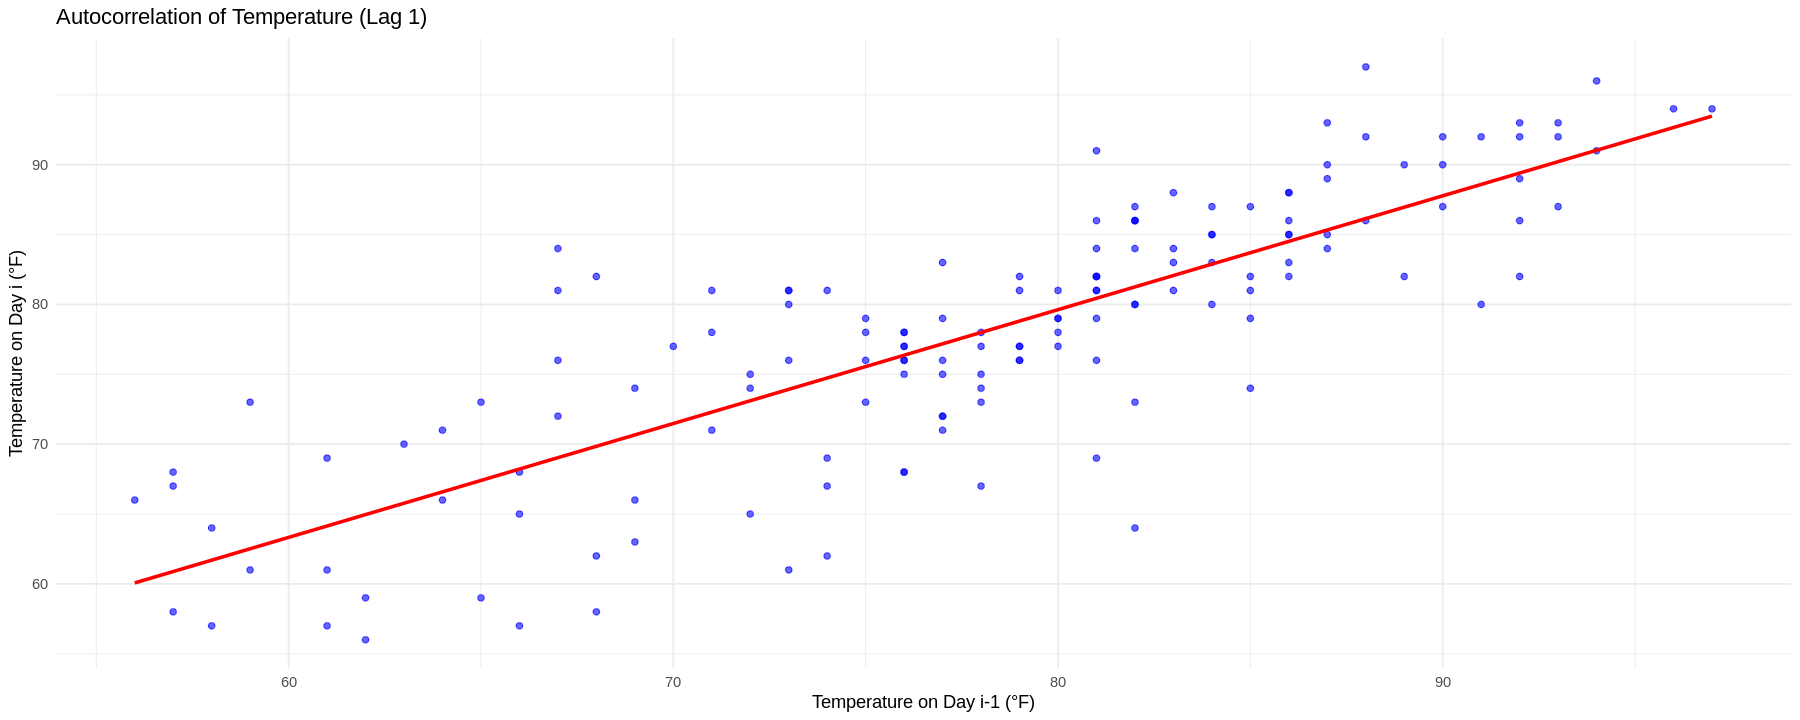

In [66]:
library(ggplot2)
library(dplyr)

# load dataset
data("airquality")

# create Day Number
airquality <- airquality %>%
  mutate(DayNumber = case_when(
    Month == 5 ~ Day,
    Month == 6 ~ 31 + Day,
    Month == 7 ~ 31 + 30 + Day,
    Month == 8 ~ 31 + 30 + 31 + Day,
    Month == 9 ~ 31 + 30 + 31 + 31 + Day
  )) %>%
  arrange(Month, Day)  # ensure sorted by time

# remove NA temperatures
temp_data <- airquality %>% filter(!is.na(Temp))

# create lagged temperatures
Temp_i   <- temp_data$Temp[-1]        # day i
Temp_i_1 <- temp_data$Temp[-nrow(temp_data)]  # day i-1

# ---- plot ----
ggplot(data.frame(Temp_i, Temp_i_1), aes(x = Temp_i_1, y = Temp_i)) +
  geom_point(color = "blue", alpha = 0.6) +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  theme_minimal() +
  labs(
    title = "Autocorrelation of Temperature (Lag 1)",
    x = "Temperature on Day i-1 (°F)",
    y = "Temperature on Day i (°F)"
  )

# ---- calculate autocorrelation using the custom function ----
autocorr_lag1 <- Calculate_Correlation(Temp_i, Temp_i_1)
cat("Autocorrelation (lag 1) =", autocorr_lag1, "\n")


###5. We want to expand on this idead and calcualte correlation for shifts 1 to 100 and plot correlation of temperature with previous days.

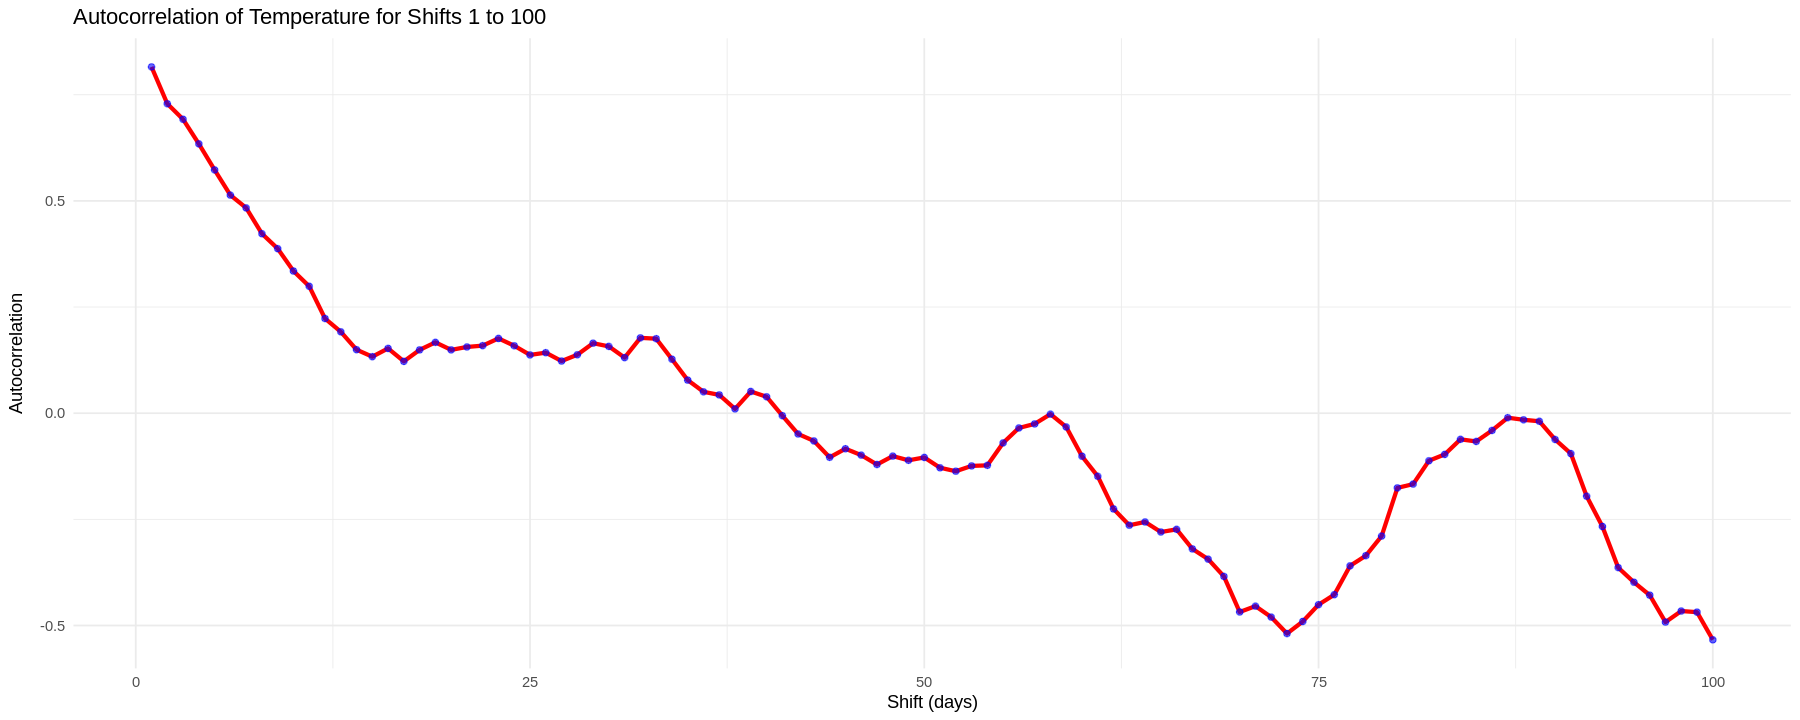

In [67]:
library(ggplot2)
library(dplyr)

# load dataset
data("airquality")

# create Day Number
airquality <- airquality %>%
  mutate(DayNumber = case_when(
    Month == 5 ~ Day,
    Month == 6 ~ 31 + Day,
    Month == 7 ~ 31 + 30 + Day,
    Month == 8 ~ 31 + 30 + 31 + Day,
    Month == 9 ~ 31 + 30 + 31 + 31 + Day
  )) %>%
  arrange(Month, Day)  # ensure sorted by time

# remove NA temperatures
temp_data <- airquality %>% filter(!is.na(Temp))
Temp <- temp_data$Temp
n <- length(Temp)

# compute autocorrelations for shifts 1 to 100
max_shift <- 100
shifts <- 1:max_shift
autocorr <- numeric(length = max_shift)

for (s in shifts) {
  Temp_i   <- Temp[(s+1):n]
  Temp_i_s <- Temp[1:(n-s)]
  autocorr[s] <- Calculate_Correlation(Temp_i, Temp_i_s)
}

# create dataframe for plotting
df_acf <- data.frame(Shift = shifts, Autocorrelation = autocorr)

# plot
ggplot(df_acf, aes(x = Shift, y = Autocorrelation)) +
  geom_line(color = "red", size = 1.2) +
  geom_point(color = "blue", size = 1.5, alpha = 0.6) +
  theme_minimal() +
  labs(
    title = "Autocorrelation of Temperature for Shifts 1 to 100",
    x = "Shift (days)",
    y = "Autocorrelation"
  )


# Question 3 (50 points🎯)
## Conditional Distribution 🤖

For this part we want to locate a robot (WALL-E) in a 10 by 15 grid like maze using it's
sensors.

WALL-E has 4 sensors in its 4 directions that inform it of the presence or absence of a wall in each direction. Each of these 4 sensors has a 10% error. The probability distribution of the result of each sensor is as follows:

$$P(\text{sensor} = 1 | \text{wall} = 1) = 0.9$$
$$P(\text{sensor} = 1 | \text{wall} = 0) = 0.1$$
$$P(\text{sensor} = 0 | \text{wall} = 1) = 0.1$$
$$P(\text{sensor} = 0 | \text{wall} = 0) = 0.9$$

WALL-E is really old and his legs 🦿 are not what they used to be, so even if he chooses to go up, he may go south!!!

given each intended direction, there is a probability of 80% of correctly moving
and 20% moving in the wrong direction (uniformly).
$$P(\text{move} = \text{UP} | \text{intendedDir} = \text{UP}) = 0.8$$
$$P(\text{move} = \text{DOWN} | \text{intendedDir} = \text{UP}) = \frac{0.2}{3}$$
$$P(\text{move} = \text{RIGHT} | \text{intendedDir} = \text{UP}) = \frac{0.2}{3}$$
$$P(\text{move} = \text{LEFT} | \text{intendedDir} = \text{UP}) = \frac{0.2}{3}$$

WALL-E may be old but it has a strong memory 🧠, it stores the history of it's beliefs(the probability of being at each cell each step, more on this later)

WALL-E  wants to find it's location with high accuracy using probabilistic methods and conditional probability to escape from the maze!!! 🌽

To solve this problem, we model it with a set of random variables. Suppose that $X_t$ represents the robot's location after t movements.
Initially the probability of the robot being present in all blocks is equal,
meaning the initial probability for each block (x,y) is:
$$P(X_{0} = (x,y)) = \frac{1}{\text{NUM OF FREE CELLS}}$$

Also, suppose we denote the data read from the sensors at time t by $E_t$ (evidence after t movements 🕵️).



**Common Mistake ✖️**

Random variables $X_{t}$ and $E_{t}$ are vectors!!!

$X_{t}$ shows the location of WALL-E using x,y coordinates for example [3,4].

$E_{t}$ shows the status of WALL-E's sensors for example [0,0,0,1] (only one sensor is on while the others are off)

In our model, $X_{t}$ only depends on $X_{t-1}$ and each $E_t$ also only depends on $X_{t}$ (independent from other random variables).

we can consider a set of random variables:

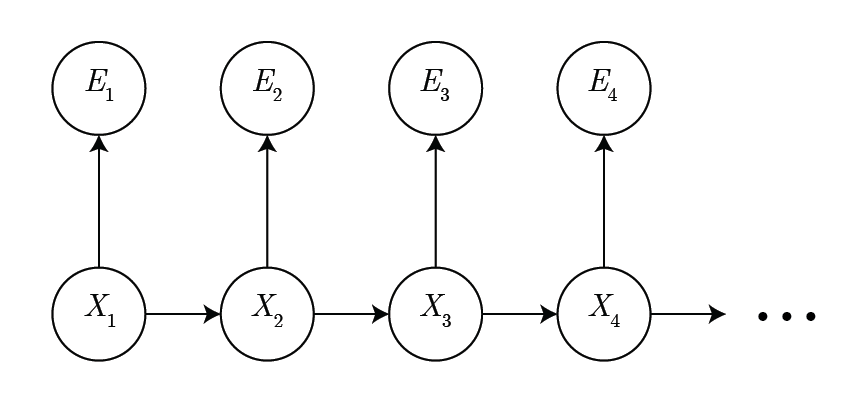


Each arrow indicates the dependence of the variable at the end of the arrow on the variable at the beginning of the arrow.

**What are we looking for? 🔍**

we are looking to estimate $X_t$ from evidences $E_1$ to $E_t$ for each block of the map. So for each step we need to obtain the following probability value:

$$ P(X_{t} | E_1, E_2, ... E_t)$$

This probability can be written as:

$$ { \color{#55cffd} {P(X_t|E_{1:t}) \propto P(X_t, E_{1:t}) \
= \sum_{X_{t-1}} P(X_{t-1}, X_t, E_{1:t}) \
= \sum_{X_{t-1}} P(X_{t-1}, E_{1:t-1}) P(X_t|X_{t-1}) P(E_t|X_t) \
\propto P(E_t|X_t) \sum_{X_{t-1}} P(X_t|X_{t-1}) P(X_{t-1} \mid E_{1:t-1})}}$$

So we will need 3 probabilities:

1. $ P(E_t|X_t) $
2. $ P(X_t|X_{t-1}) $
3. $ P(X_{t-1}, E_{1:t-1}) $

### 0. Theoretical Calculation of Presence Probability (5 points)**

- Assume we have a $2 \times 3$ grid as shown below.


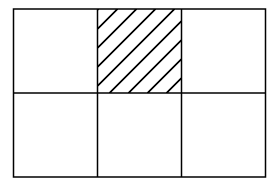

If the robot selects the **DOWN** direction and, after moving, makes the following observation:

$$E_2 = [ \text{UP} = 0, \text{RIGHT} = 0, \text{DOWN} = 1, \text{LEFT} = 1 ]$$

Then, calculate:

$$P(X_2|E_{1:2})$$

(Assume that $P(X_1|E_1)$ is uniformly $0.2$ for all empty cells).

Is the result as expected?

🔴 **0. TO DO**

In [68]:
# ---- Setup ----

# grid dimensions
rows <- 2
cols <- 3

# initial belief P(X1|E1) = 0.2 for all cells
belief_X1 <- matrix(0.2, nrow = rows, ncol = cols)

# movement probabilities (intended DOWN)
p_correct <- 0.8
p_wrong <- 0.2 / 3  # uniform for other 3 directions

# sensor probabilities
p_s1_w1 <- 0.9  # sensor=1|wall=1
p_s1_w0 <- 0.1  # sensor=1|wall=0
p_s0_w1 <- 0.1  # sensor=0|wall=1
p_s0_w0 <- 0.9  # sensor=0|wall=0

# sensor reading E2 = [UP, RIGHT, DOWN, LEFT]
E2 <- c(0,0,1,1)

# define walls for each cell (1=wall, 0=no wall)
# format: [UP, RIGHT, DOWN, LEFT]
walls <- list(
  "1,1" = c(1,0,0,1),
  "1,2" = c(1,0,0,0),
  "1,3" = c(1,1,0,0),
  "2,1" = c(0,0,1,1),
  "2,2" = c(0,0,1,0),
  "2,3" = c(0,1,1,0)
)

# ---- Function to compute sensor likelihood ----
sensor_likelihood <- function(cell_walls, E) {
  prob <- 1
  for(i in 1:4){
    if(E[i] == 1 & cell_walls[i] == 1) prob <- prob * p_s1_w1
    if(E[i] == 1 & cell_walls[i] == 0) prob <- prob * p_s1_w0
    if(E[i] == 0 & cell_walls[i] == 1) prob <- prob * p_s0_w1
    if(E[i] == 0 & cell_walls[i] == 0) prob <- prob * p_s0_w0
  }
  return(prob)
}

# ---- Transition probability function ----
transition_prob <- function(X1, X2){
  # X1 and X2 are c(row,col)
  intended_move <- c(1,0)  # DOWN
  delta <- X2 - X1
  # check if move matches intended
  if(all(delta == intended_move)) return(p_correct)
  # check if move matches other directions
  other_dirs <- list(c(-1,0), c(0,1), c(0,-1)) # UP, RIGHT, LEFT
  for(d in other_dirs){
    if(all(delta == d)) return(p_wrong)
  }
  return(0)
}

# ---- Compute P(X2|E1:E2) ----
belief_X2 <- matrix(0, nrow = rows, ncol = cols)

for(r2 in 1:rows){
  for(c2 in 1:cols){
    sum_prob <- 0
    for(r1 in 1:rows){
      for(c1 in 1:cols){
        sum_prob <- sum_prob + transition_prob(c(r1,c1), c(r2,c2)) * belief_X1[r1,c1]
      }
    }
    cell_key <- paste(r2,c2,sep=",")
    belief_X2[r2,c2] <- sum_prob * sensor_likelihood(walls[[cell_key]], E2)
  }
}

# ---- Normalize ----
belief_X2 <- belief_X2 / sum(belief_X2)

# ---- Print result ----
belief_X2


0.00167454,0.00027909,2.067333e-05
0.88164518,0.10549600,1.088451e-02


### Basic definitions
This section contains the map, list of movements and constant values.
+ 🔴 **You do not need to change this section.**

+ The function `generate_directions` generates a sequence of moves specified by the strings u, l, d, r and outputs the list of moves.

In [69]:
generate_directions <- function(map, start_pos = c(2, 3), n = 300, valid_ratio = 0.9) {
  directions <- c("u", "d", "l", "r")
  moves <- list(u = c(-1, 0), d = c(1, 0), l = c(0, -1), r = c(0, 1))

  pos <- start_pos
  chosen_dirs <- character(0)
  valid_moves <- 0

  NUM_ROWS <- nrow(map)
  NUM_COLS <- ncol(map)

  while (length(chosen_dirs) < n) {
    dir <- sample(directions, 1)
    new_pos <- pos + moves[[dir]]

    if (new_pos[1] < 1 || new_pos[1] > NUM_ROWS ||
        new_pos[2] < 1 || new_pos[2] > NUM_COLS ||
        map[new_pos[1], new_pos[2]] == 1) {
      if (runif(1) > valid_ratio) {
        chosen_dirs <- c(chosen_dirs, dir)
      }
    } else {
      pos <- new_pos
      chosen_dirs <- c(chosen_dirs, dir)
      valid_moves <- valid_moves + 1
    }
  }

  return(chosen_dirs)
}

In [70]:
map <- matrix(c(
  1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
  1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
  1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
  1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
  1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
  1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
  1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
  1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1,
  1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
  1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
), nrow = 15, ncol = 10) %>% t()

dim = dim(map)

NUM_ROWS = dim[1]
NUM_COLS = dim[2]
SENSOR_ERROR = 0.1
MOVE_ERROR = 0.2
INITIAL_POS = c(2,3)

# List of robot movements Generated by a function. You can change the percentage of moves that are valid (do not hit the wall) and the number of moves.
# The output is a list of 4 letters u, d, l, r.
chosen_dirs <- generate_directions(map, start_pos = INITIAL_POS, n = 300, valid_ratio = 0.9)

actions <- list(
  u = c(y = -1, x = 0),
  d = c(y = 1, x = 0),
  l = c(y = 0, x = -1),
  r = c(y = 0, x = 1)
)

action_names <- names(actions)


###  1. Finding The Evidence!!! 🔍
+ a function that takes WALL-E's current position and the map and returns the values of the top, right, bottom, and left sensors (4 element list).
These are the values of WALL-E's sensors (or evidences of our model).

+ 🔴 **You do not need to change this section.**


In [71]:
sensor <- function(map, current_pos) {

  get_single_reading <- function(target_pos) {

    is_wall_present <- FALSE
    if (map[target_pos[1], target_pos[2]] == 1) {
      is_wall_present <- TRUE
    }
    true_value <- ifelse(is_wall_present, 1, 0)

    random_chance <- runif(1)
    if (random_chance <= (1 - SENSOR_ERROR)) {
      return(true_value)
    }
    else {
      return(1 - true_value)
    }
  }

  pos_up <- current_pos + actions$u
  pos_down <- current_pos + actions$d
  pos_left <- current_pos + actions$l
  pos_right <- current_pos + actions$r

  reading_up <- get_single_reading(pos_up)
  reading_down <- get_single_reading(pos_down)
  reading_left <- get_single_reading(pos_left)
  reading_right <- get_single_reading(pos_right)

  return(list(u = reading_up, r = reading_right, d = reading_down, l = reading_left))
}

### 2. **TO-DO:** Find WALL-E's Next Position 🔍 (10 points🎯)
+ Write a function that takes WALL-E's current position and it's chosen direction and returns the position after the movement.

In [72]:
move <- function(map, current_pos, chosen_dir, move_error = MOVE_ERROR) {
  # تعریف حرکات ممکن
  actions <- list(
    u = c(-1, 0),
    d = c(1, 0),
    l = c(0, -1),
    r = c(0, 1)
  )

  # تمام جهت‌های ممکن
  directions <- names(actions)

  # تعیین جهت واقعی حرکت با توجه به خطا
  random_val <- runif(1)

  if(random_val <= (1 - move_error)) {
    # حرکت درست
    actual_dir <- chosen_dir
  } else {
    # حرکت اشتباه (انتخاب یکنواخت از سه جهت دیگر)
    other_dirs <- setdiff(directions, chosen_dir)
    actual_dir <- sample(other_dirs, 1)
  }

  # محاسبه موقعیت جدید
  new_pos <- current_pos + actions[[actual_dir]]

  # بررسی دیوار و مرزها
  n_rows <- nrow(map)
  n_cols <- ncol(map)

  if(new_pos[1] < 1 || new_pos[1] > n_rows ||
     new_pos[2] < 1 || new_pos[2] > n_cols ||
     map[new_pos[1], new_pos[2]] == 1) {
    # برخورد با دیوار یا خارج از محدوده، موقعیت ثابت می‌ماند
    return(current_pos)
  }

  return(new_pos)
}

current_pos <- c(2,3)
chosen_dir <- "u"

new_pos <- move(map, current_pos, chosen_dir)
print(new_pos)



[1] 2 3


### 3.  **TO-DO:** Calculating $ P(E_t|X_t) $ 🧮 (10 points🎯)
+ 3.1. Theoritically calculate the above probability using $E_t = [0,1,0,1]$ and $X_t = [3,4]$ for the map given above.
+ 3.2. Write a function that takes the last evidence ($E_t$) and WALL-E's position ($X_t$) and return the probability $ P(E_t|X_t) $.
+ 3.3. Check your 3.1. answer using 3.2. function

🔴 **3.1 TO DO**

3.2. **$ P(E_t|X_t) $ Function**

In [73]:
cal_observation_prob <- function(map, xt, et) {
  # xt = c(row, col)
  # et = list(u=0/1, r=0/1, d=0/1, l=0/1)

  # احتمال سنسور
  SENSOR_ERROR <- 0.1
  p_s1_w1 <- 1 - SENSOR_ERROR
  p_s0_w1 <- SENSOR_ERROR
  p_s1_w0 <- SENSOR_ERROR
  p_s0_w0 <- 1 - SENSOR_ERROR

  # حرکات
  actions <- list(
    u = c(-1, 0),
    d = c(1, 0),
    l = c(0, -1),
    r = c(0, 1)
  )

  prob <- 1

  for(dir in names(actions)) {
    new_pos <- xt + actions[[dir]]
    # بررسی مرزهای map
    n_rows <- nrow(map)
    n_cols <- ncol(map)

    if(new_pos[1] < 1 || new_pos[1] > n_rows ||
       new_pos[2] < 1 || new_pos[2] > n_cols) {
      wall <- 1
    } else {
      wall <- map[new_pos[1], new_pos[2]]
    }

    sensor_val <- et[[dir]]

    if(sensor_val == 1 & wall == 1) prob <- prob * p_s1_w1
    if(sensor_val == 1 & wall == 0) prob <- prob * p_s1_w0
    if(sensor_val == 0 & wall == 1) prob <- prob * p_s0_w1
    if(sensor_val == 0 & wall == 0) prob <- prob * p_s0_w0
  }

  return(prob)
}
xt <- c(3,4)
et <- list(u=0, r=1, d=0, l=1)

# محاسبه احتمال
P_et_Xt <- cal_observation_prob(map, xt, et)
P_et_Xt

[1] 0.0729

3.3. **Comparing the results**

In [74]:
# --- Define position and evidence ---
xt <- c(3,4)
et <- list(u=0, r=1, d=0, l=1)

# --- Call the function ---
P_et_Xt <- cal_observation_prob(map, xt, et)

# --- Print result ---
cat("P(E_t | X_t = (3,4)) =", P_et_Xt, "\n")


P(E_t | X_t = (3,4)) = 0.0729 


### 4. **TO-DO:** Calculating $ P(X_t|X_{t-1}) $ 🧮 (10 points🎯)
+ Write a function that takes $X_t$, $X_{t-1}$, and the direction chosen by the WALL-E and outputs the probability that WALL-E will go from $X_{t-1}$ to $X_t$ given the input direction.

+ For example, `f((3,4), (3,5) , 'u')` is equal to the probability that WALL-E will go from house (3,5) to (3,4) while choosing the up direction.

+ Note: If $X_{t-1}$ were a wall, we would return 0.

+ Note: If $X_{t-1}$ were not a neighbor of $X_t$ or $X_t$ itself, it is clearly impossible for the robot to go from $X_{t-1}$ to $X_t$. So we would return 0.

+ Note: If $X_t$ were a wall, we would return 0.

In [75]:
cal_move_prob <- function(map, xt, xt_minus_1, chosen_dir, move_error = MOVE_ERROR) {
  # اگر X_{t-1} یا X_t دیوار باشد → احتمال = 0
  if(map[xt_minus_1[1], xt_minus_1[2]] == 1 || map[xt[1], xt[2]] == 1) {
    return(0)
  }

  # تعریف حرکات
  actions <- list(
    u = c(-1, 0),
    d = c(1, 0),
    l = c(0, -1),
    r = c(0, 1)
  )

  # اختلاف موقعیت
  delta <- xt - xt_minus_1

  # اگر X_t همان X_{t-1} باشد، بررسی برخورد با دیوار یا حرکت اشتباه
  if(all(delta == 0)) {
    # در اینجا می‌توانیم فرض کنیم احتمال حرکت اشتباه به دیوار → موقعیت ثابت
    return(0)  # یا بسته به مدل می‌توان مقدار دیگری داد
  }

  # اگر اختلاف با هیچ یک از حرکات ممکن برابر نباشد → غیرممکن
  possible_dirs <- names(actions)
  match_dir <- NULL
  for(dir in possible_dirs) {
    if(all(delta == actions[[dir]])) {
      match_dir <- dir
      break
    }
  }
  if(is.null(match_dir)) return(0)

  # محاسبه احتمال حرکت
  if(match_dir == chosen_dir) {
    return(1 - move_error)  # حرکت صحیح
  } else {
    # حرکت اشتباه: احتمال تقسیم یکنواخت بین 3 جهت دیگر
    return(move_error / 3)
  }
}


### 5. **TO-DO:** Main program loop 🔁 (10 points🎯)

+ Write the main loop using the model's formula provided to calculate $P(X_t| E_{1:t})$
+ Don't forget to normalize !! you can use the normalize function below to normalize the belief.

Complete the `model` function so that it returns a binary list of the model's beliefs and the robot's actual positions by taking the map and the chosen directions of the robot:

`return (list(beliefs = beliefs, real_pos = real_pos))`

#### Initializing
Initializing the belief list and the WALL-E's actual position
+ Note: The `beliefs` is a list to store WALL-E's belief about its location at each time step. Each element in this list will be a matrix representing the probability distribution of the robot being in each cell of the grid (belief). Initially, we add a uniform distribution to it.

❗ Beliefs is used to simulate our model and real postions is used to simulate real tracking of WALL-E. we can find our model's perfomance by comparing
beliefs and real positions.

In [76]:
normalize <- function(m) {
  total_sum <- sum(m)
  normalized_m <- m / total_sum
  return(normalized_m)
}

In [77]:
model <- function(map, chosen_dirs) {

  current_pos <- INITIAL_POS
  real_pos <- list()
  beliefs <- list()

  # initialize uniform belief
  initial_probs <- function(map) {
    num_zeros <- sum(map == 0)
    if(num_zeros == 0) return(matrix(0, nrow = nrow(map), ncol = ncol(map)))
    replacement_value <- 1 / num_zeros
    output_mat <- ifelse(map == 0, replacement_value, 0)
    return(output_mat)
  }

  beliefs <- append(beliefs, list(initial_probs(map)))
  real_pos <- append(real_pos, list(INITIAL_POS))

  # main loop over chosen directions
  for(t in 1:length(chosen_dirs)) {

    chosen_dir <- chosen_dirs[t]

    # --- 1. Update real position with move function ---
    current_pos <- move(map, current_pos, chosen_dir)
    real_pos <- append(real_pos, list(current_pos))

    # --- 2. Get sensor readings ---
    et <- sensor(map, current_pos)

    # --- 3. Prediction step: sum over previous belief with transition probability ---
    prev_belief <- beliefs[[t]]
    new_belief <- matrix(0, nrow = nrow(map), ncol = ncol(map))

    for(r in 1:nrow(map)) {
      for(c in 1:ncol(map)) {
        if(map[r,c] == 1) next  # skip walls
        sum_prob <- 0
        for(r_prev in 1:nrow(map)) {
          for(c_prev in 1:ncol(map)) {
            if(map[r_prev,c_prev] == 1) next
            sum_prob <- sum_prob + cal_move_prob(map, c(r,c), c(r_prev,c_prev), chosen_dir) * prev_belief[r_prev,c_prev]
          }
        }
        # --- 4. Update with observation probability ---
        new_belief[r,c] <- sum_prob * cal_observation_prob(map, c(r,c), et)
      }
    }

    # --- 5. Normalize ---
    new_belief <- normalize(new_belief)

    # --- 6. Store new belief ---
    beliefs <- append(beliefs, list(new_belief))
  }

  return(list(beliefs = beliefs, real_pos = real_pos))
}


In [78]:
result <- model(map, chosen_dirs)
beliefs <- result$beliefs
real_pos = result$real_pos

### 6. Visualization 🎨

The following function is used to draw the Maze Heatmap.
+ 🔴 **You do not need to change this section.**

In [79]:
plot_belief_map <- function(map, belief, current_pos) {
  rows <- nrow(map)
  cols <- ncol(map)
  max_idx <- which.max(belief)
  max_belief_pos <- arrayInd(max_idx, .dim = c(rows, cols))
  plot(NA, xlim = c(0, cols), ylim = c(0, rows), type = "n",
       xlab = "", ylab = "", main = "Robot Belief State",
       xaxs = "i", yaxs = "i", xaxt = 'n', yaxt = 'n', asp = 1)
  max_b <- max(belief)
  norm_belief <- if (max_b > 0) belief / max_b else belief
  col_palette <- colorRampPalette(c("#F7FBFF", "#6BAED6", "#08306B"))(101)
  for (r in 1:rows) {
    for (c in 1:cols) {
      xleft <- c - 1
      ybottom <- rows - r
      xright <- c
      ytop <- rows - r + 1

      if (map[r, c] == 1) {
        rect(xleft, ybottom, xright, ytop, col = "grey20", border = "grey50")
      } else {
        color_idx <- floor(norm_belief[r, c] * 100) + 1
        rect(xleft, ybottom, xright, ytop, col = col_palette[color_idx], border = "grey50")
      }
    }
  }
  rect(max_belief_pos[2] - 1, rows - max_belief_pos[1],
       max_belief_pos[2], rows - max_belief_pos[1] + 1,
       border = "#00FFFF", lwd = 4)
  text(x = current_pos[2] - 0.5, y = rows - current_pos[1] + 0.5,
       labels = "X", col = "red", font = 2, cex = 2)
}

### 7. Results 🚀
Using lists `beliefs` and `real_pos`, we'll draw the maze at each step.
+ 🔴 **You do not need to change this section.**

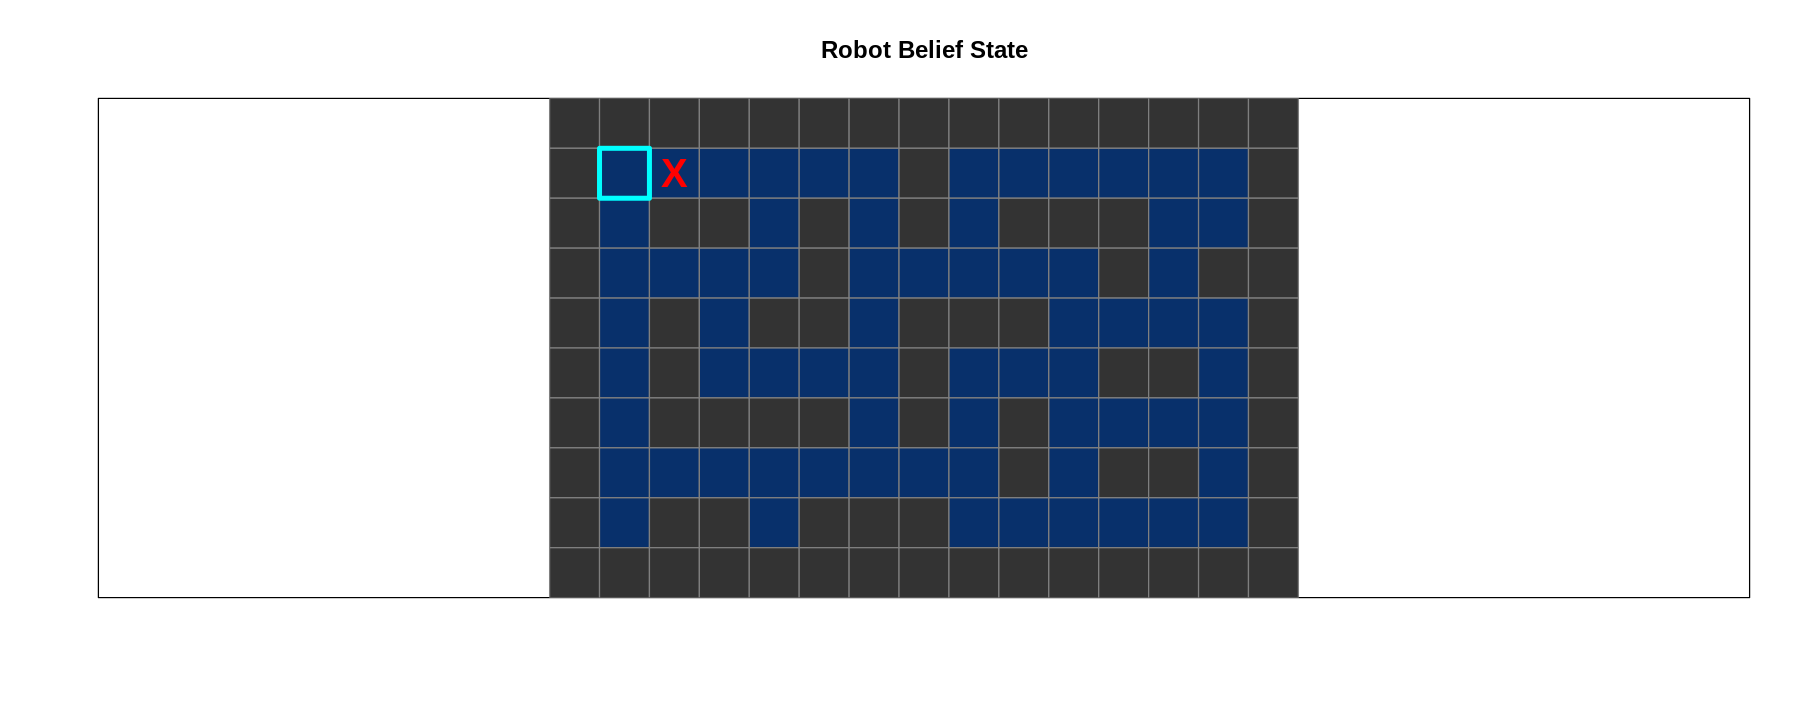

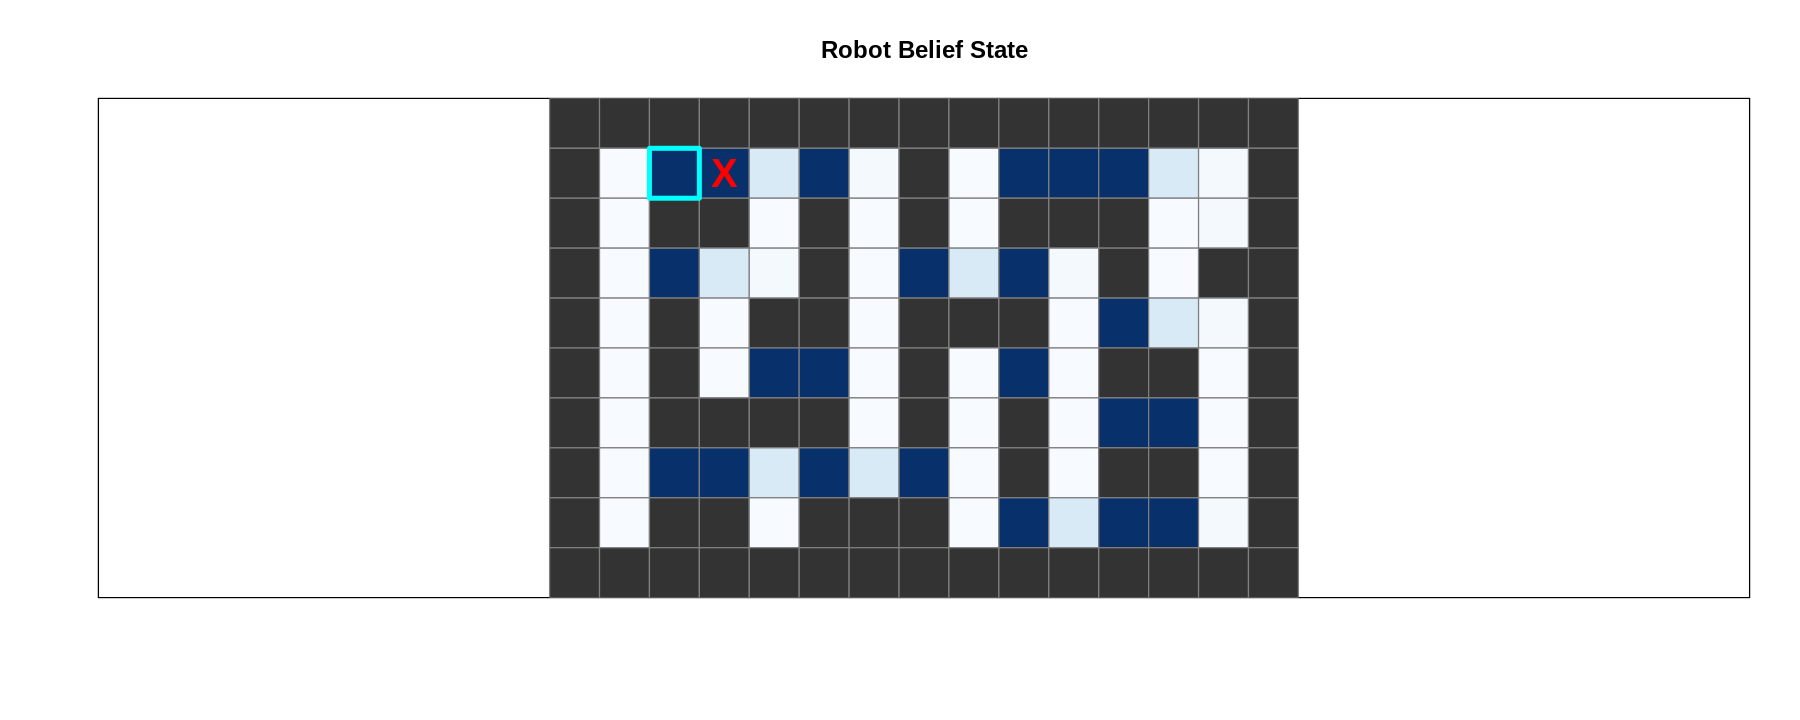

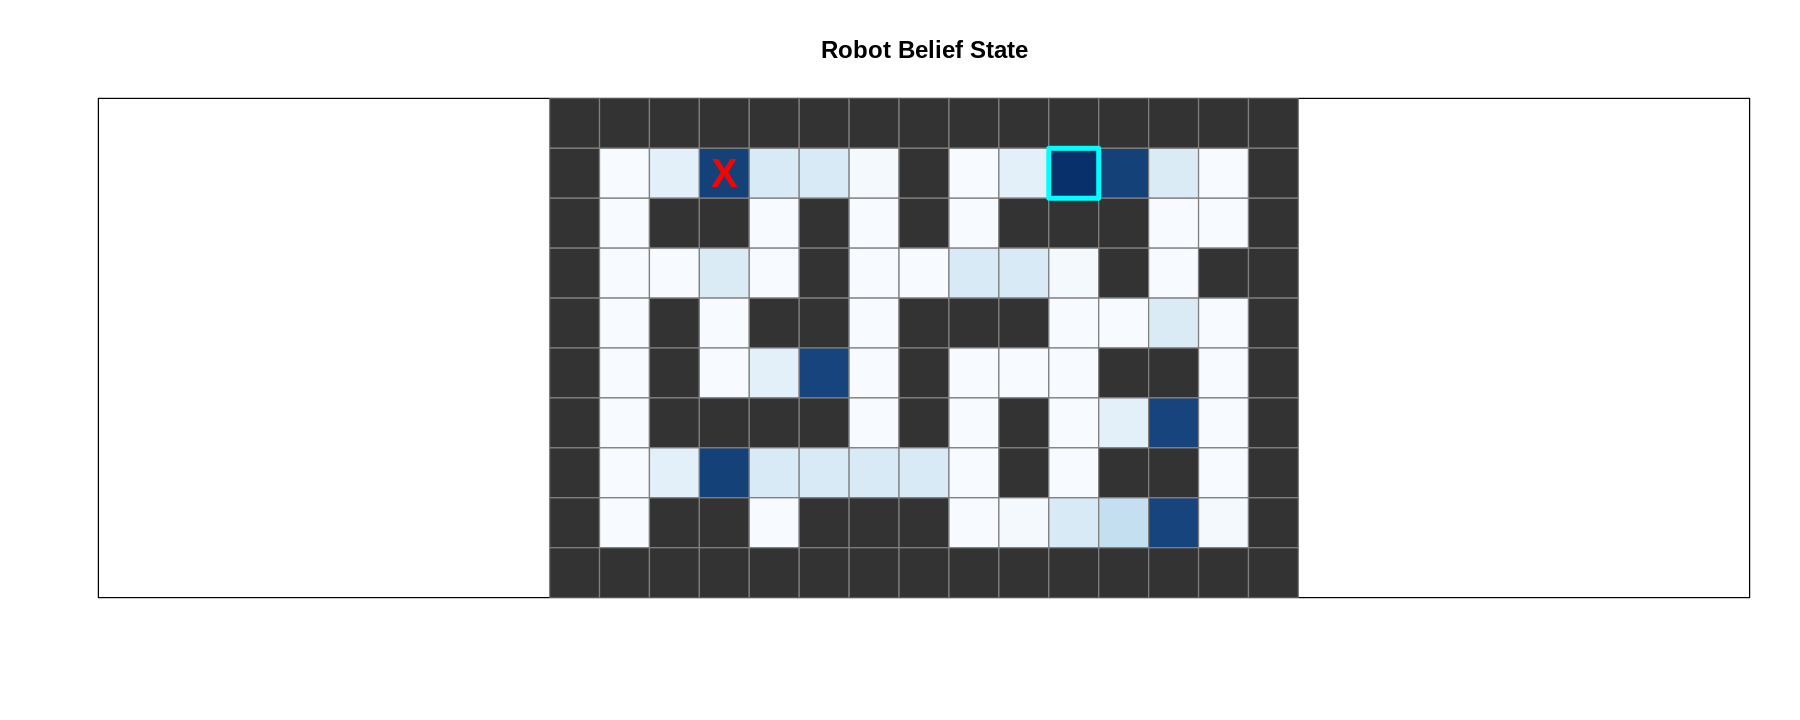

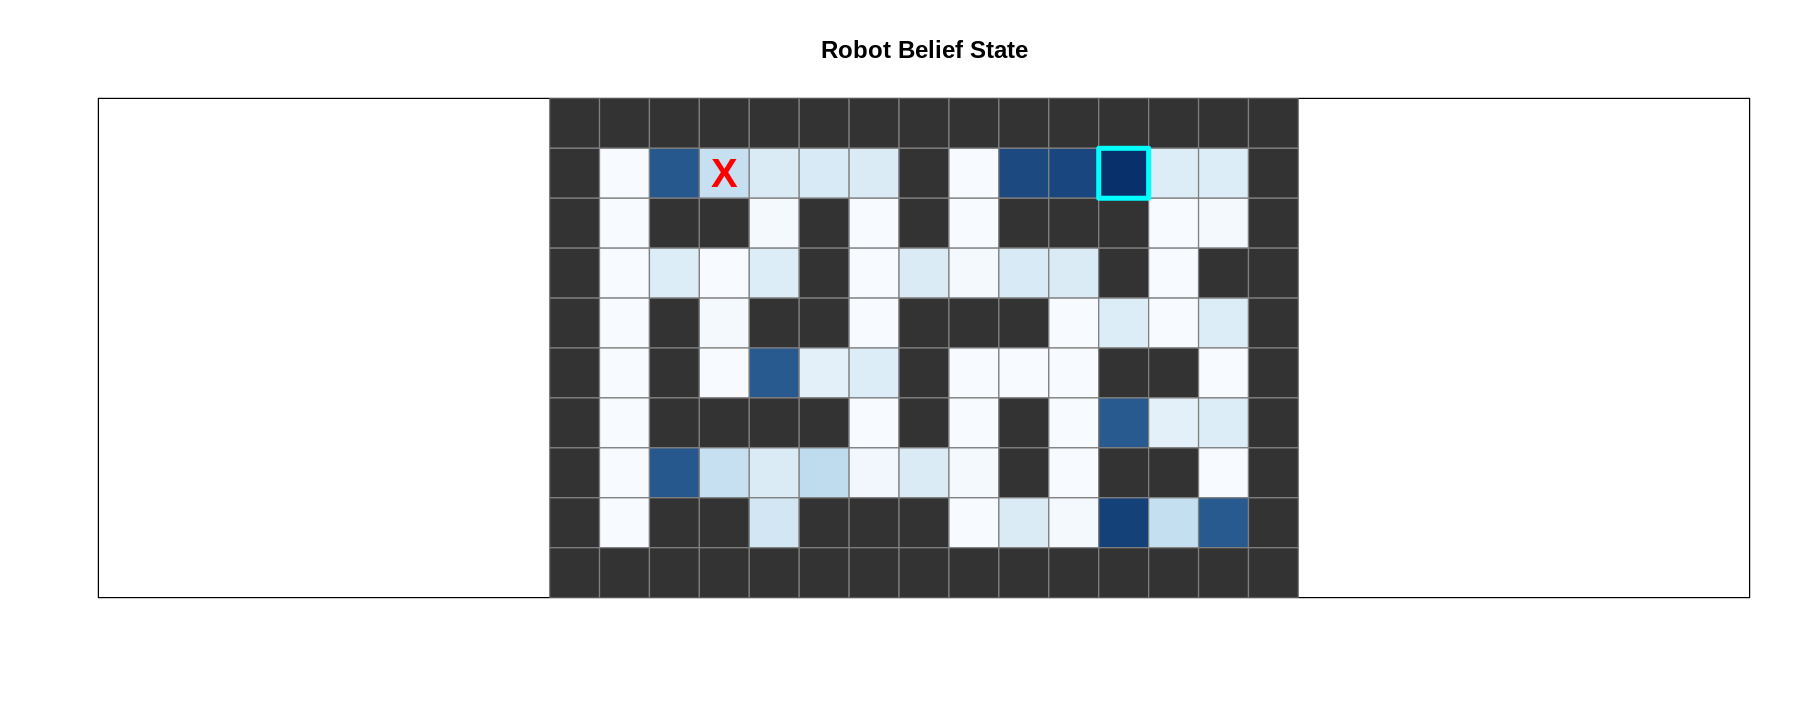

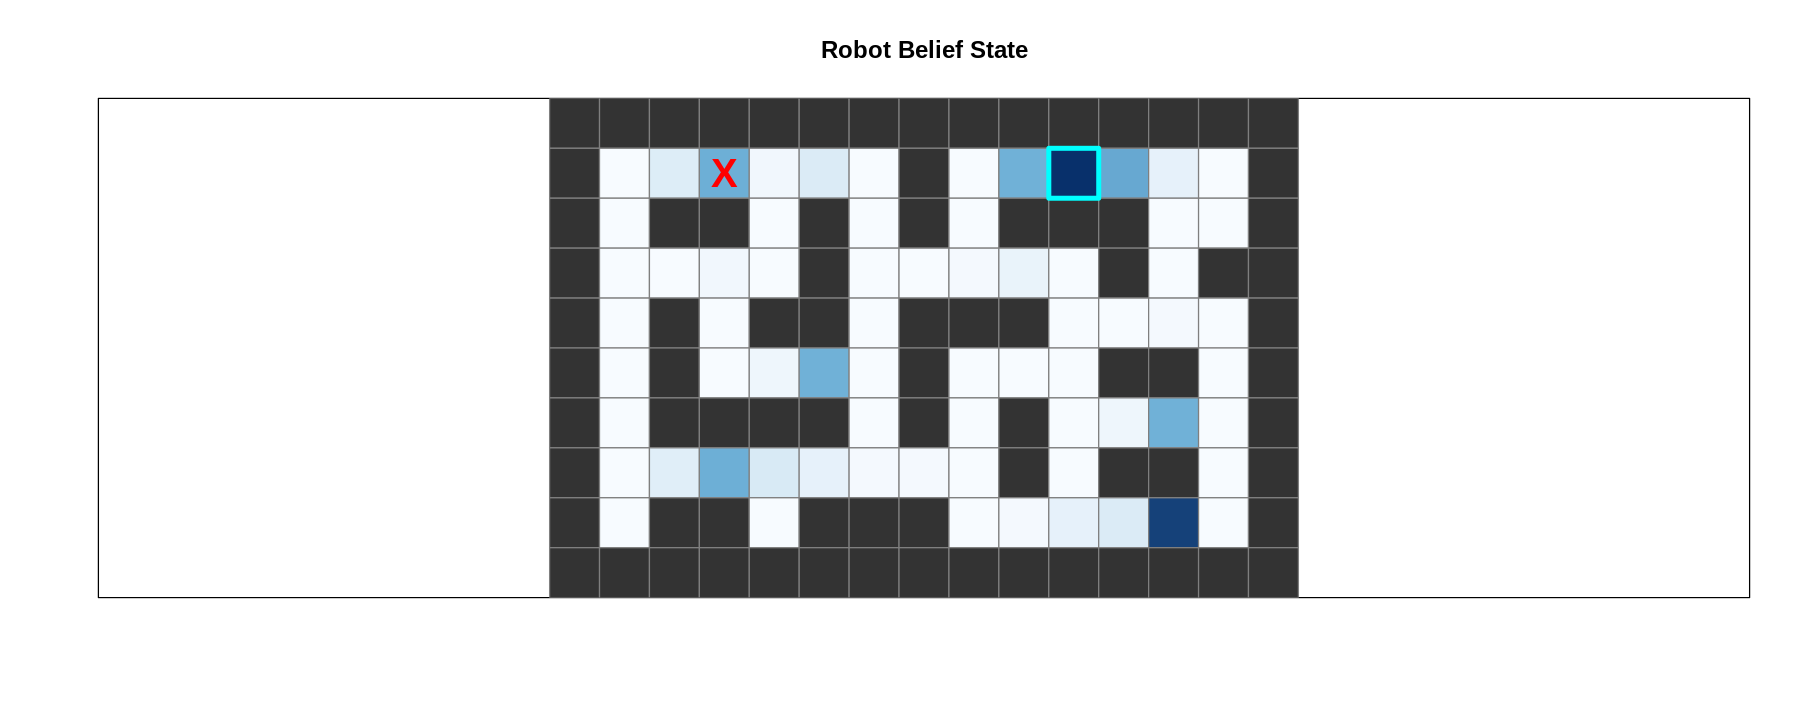

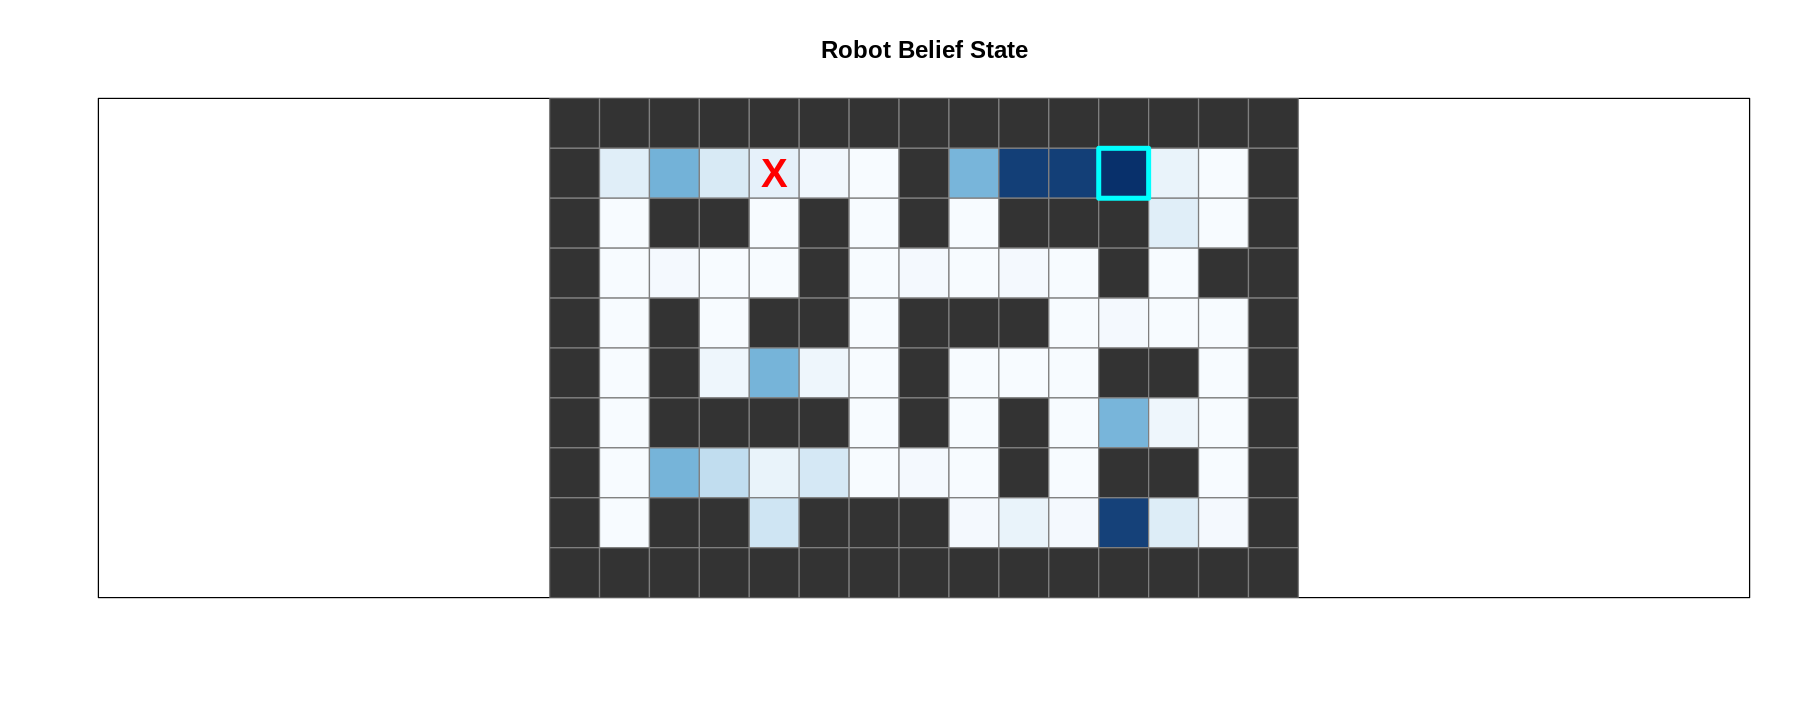

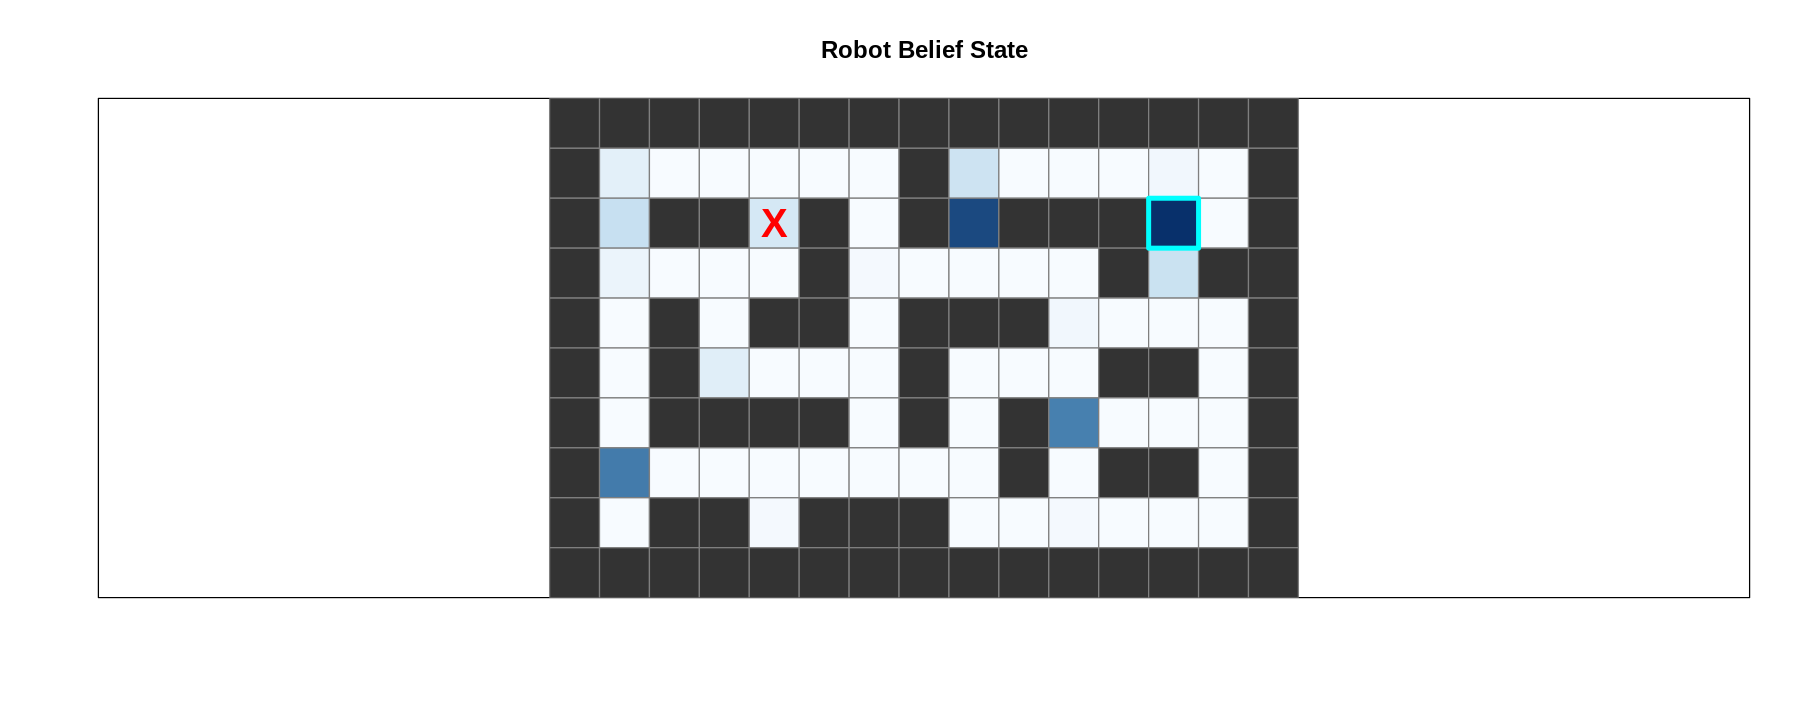

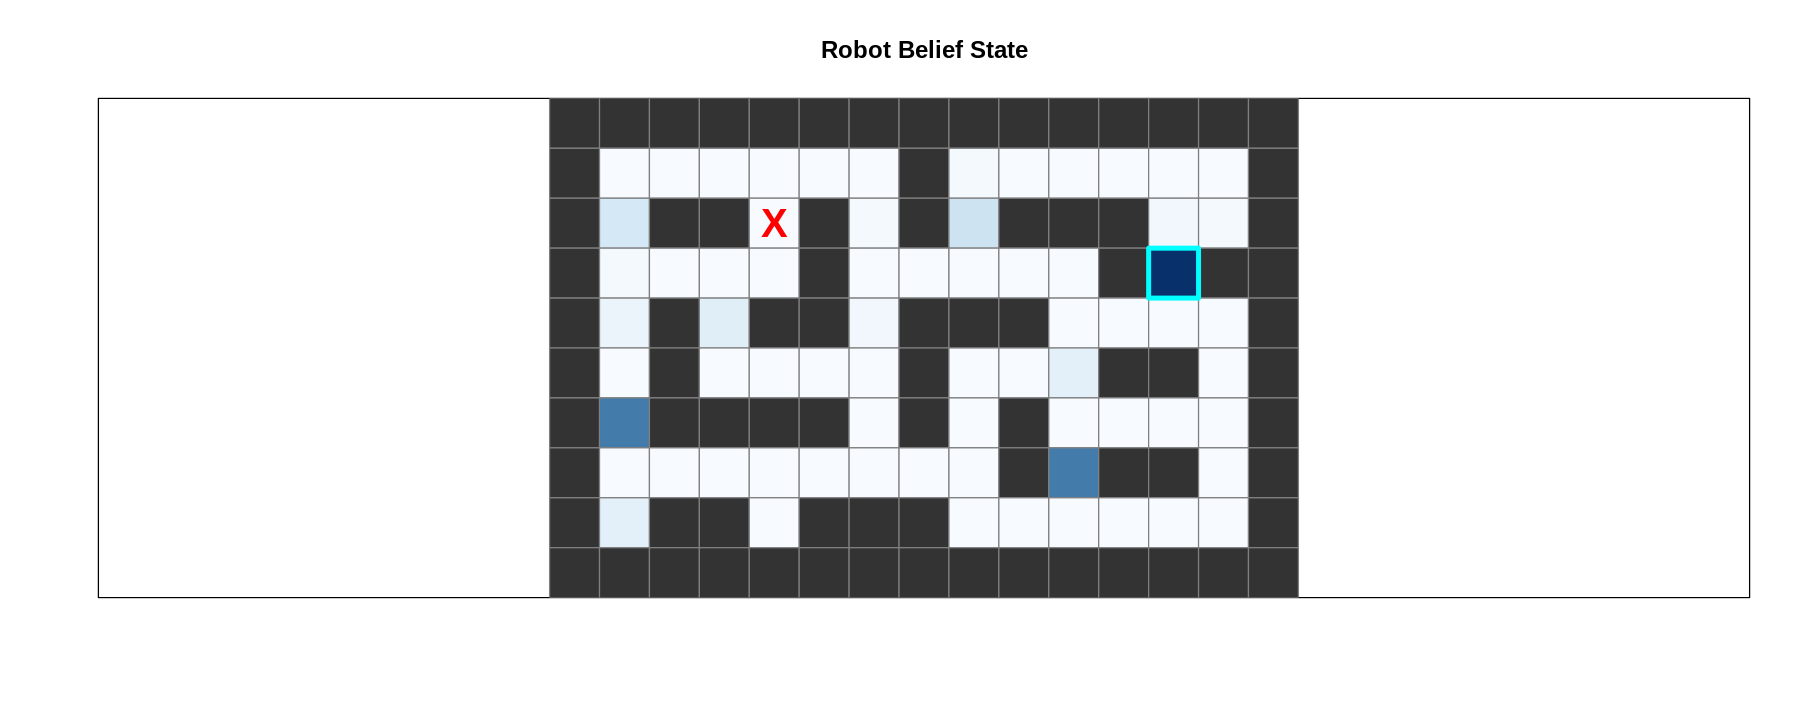

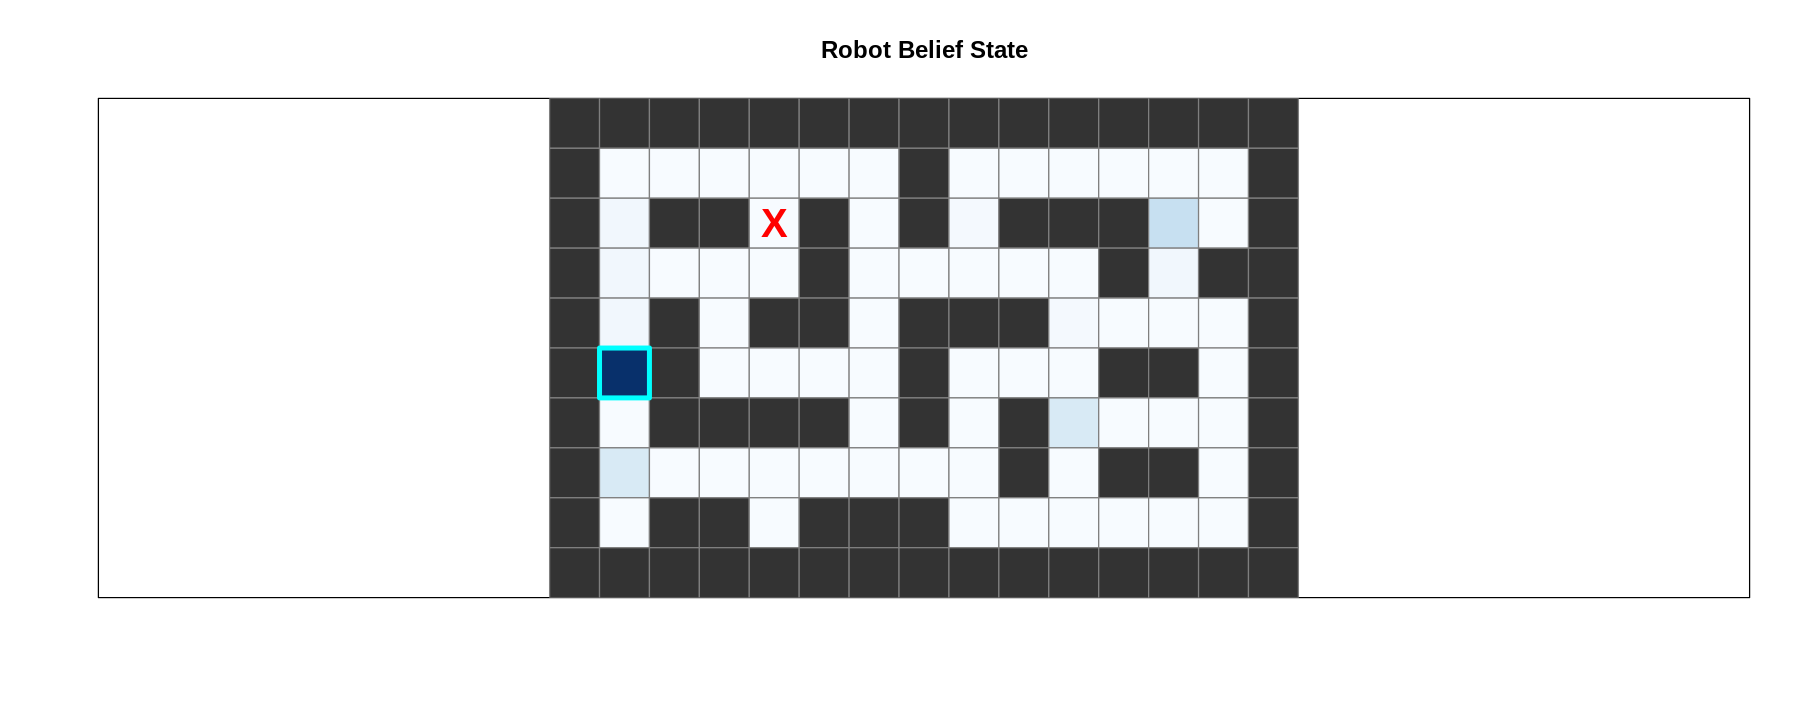

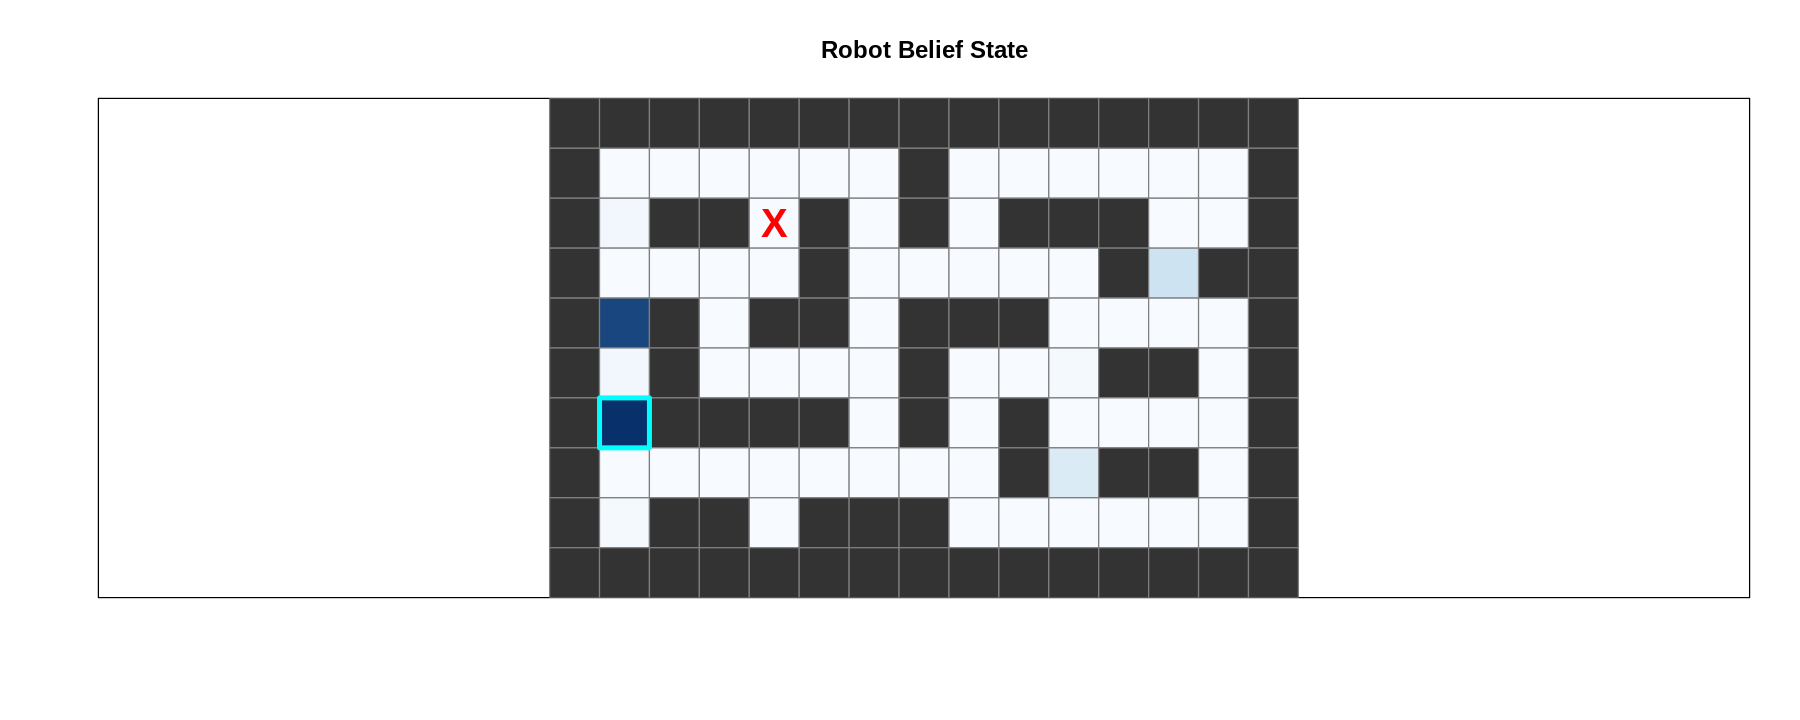

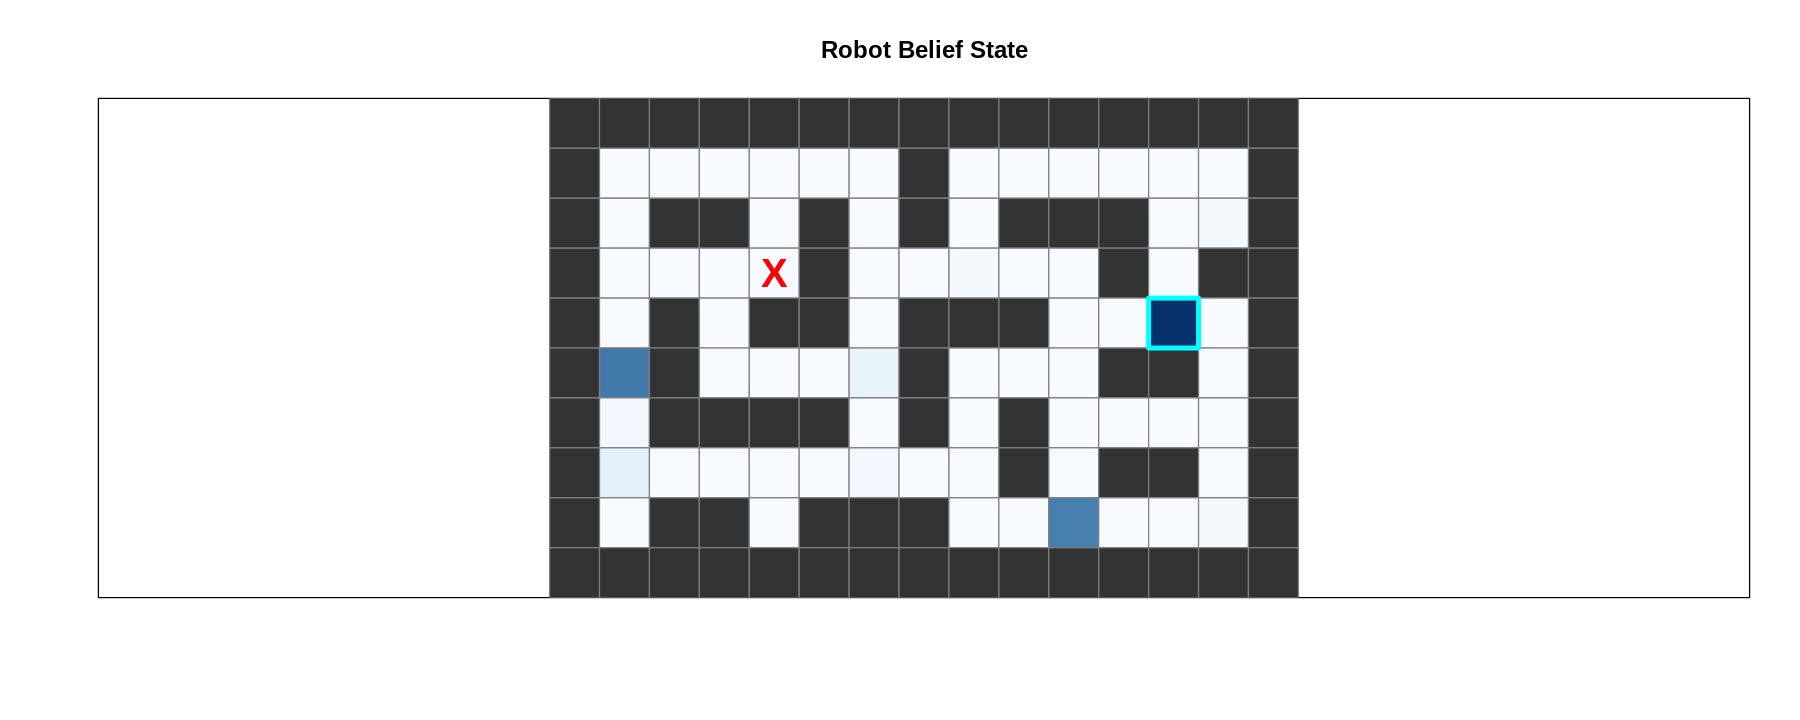

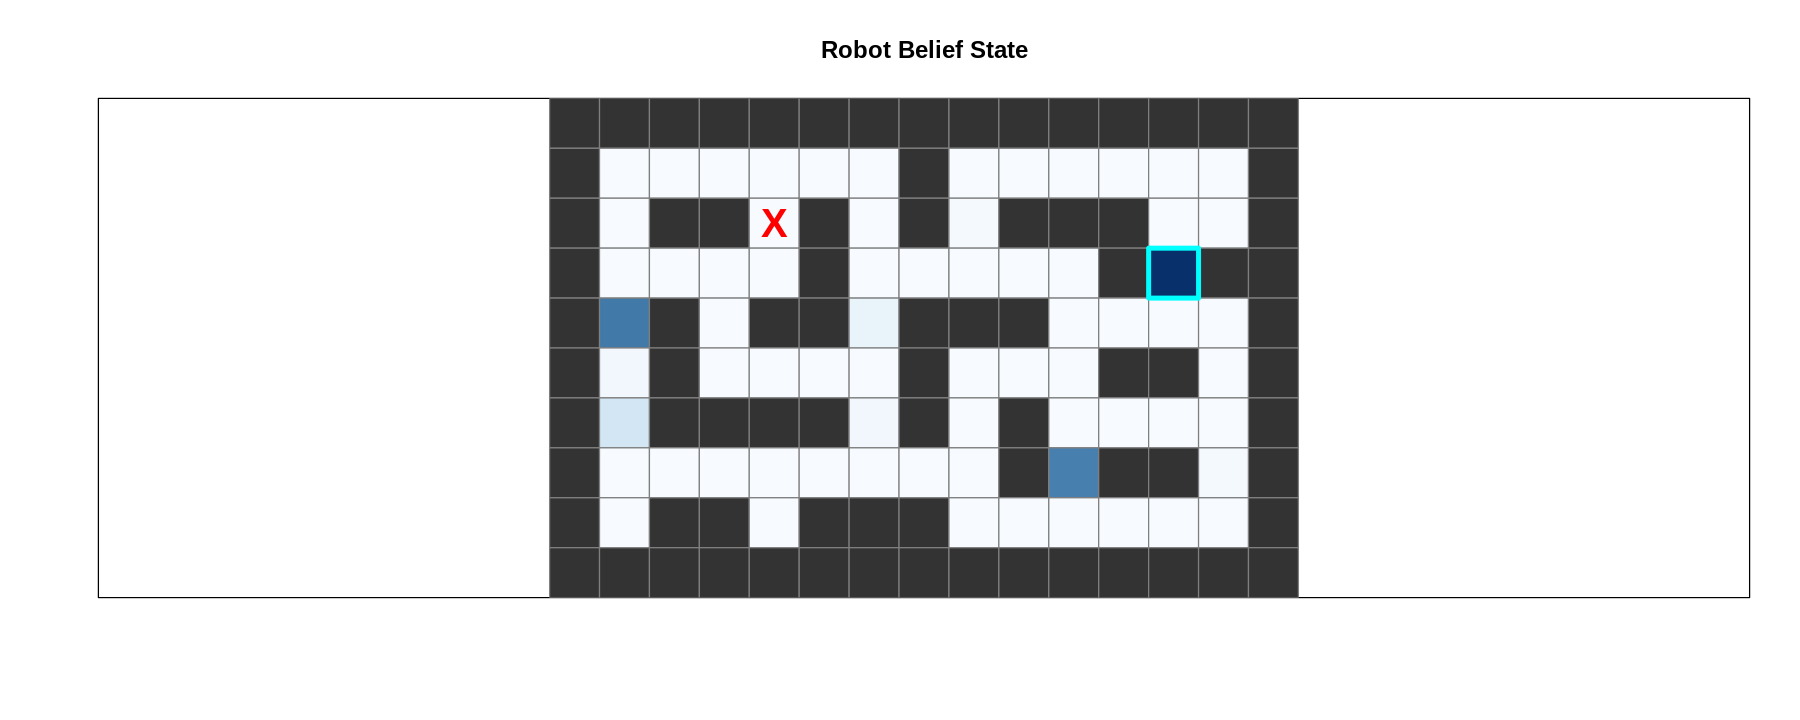

In [80]:
for(i in 1:12) {
  plot_belief_map(map, beliefs[[i]], real_pos[[i]])
}

### 8. **TO-DO:** Evaluate the results 📈 (10 points🎯)
Pass the output of your model to the following functions. Function `plot_belief_maxima` plots our maximum likelihood belief versus state. Function `plot_belief_accuracy` prints the number of correct predictions in each group of 5 along with the overall accuracy.

In [81]:
plot_belief_maxima <- function(beliefs) {
  if (!is.list(beliefs) || !all(sapply(beliefs, is.matrix))) {
    stop("Input must be a list of matrices.")
  }

    max_values <- sapply(beliefs, max)

  df <- data.frame(
    Index = seq_along(max_values),
    MaxValue = max_values
  )

  return(
    ggplot(df, aes(x = Index, y = MaxValue)) +
    geom_line(color = "blue", linewidth = 1) +
    geom_point(color = "red", size = 3) +
    labs(
      title = "Maximum Value of Each Belief Matrix",
      x = "Matrix Index",
      y = "Maximum Value"
    ) +
    theme_minimal()
  )
}


In [82]:
plot_belief_accuracy <- function(beliefs, real_pos) {
  if (length(beliefs) != length(real_pos)) {
    stop("beliefs and real_pos must have the same length.")
  }

  predicted_pos <- lapply(beliefs, function(b) {
    idx <- which(b == max(b), arr.ind = TRUE)
    return(idx[1, ])
  })

  correct <- mapply(function(p, r) all(p == r), predicted_pos, real_pos)

  n <- length(correct)
  group_indices <- ceiling(seq_len(n) / 5)
  correct_counts <- tapply(correct, group_indices, sum)

  df <- data.frame(
    Group = factor(seq_along(correct_counts)),
    Correct = as.numeric(correct_counts)
  )

  overall_acc <- mean(correct)
  cat(sprintf("Overall accuracy: %.2f%%\n", 100 * overall_acc))

  return(
    ggplot(df, aes(x = Group, y = Correct)) +
    geom_col(fill = "steelblue") +
    labs(
      title = "Correct Predictions per 5 Belief Blocks",
      x = "Group of 5 Beliefs",
      y = "Number of Correct Predictions"
    ) +
    theme_minimal()
  )

}



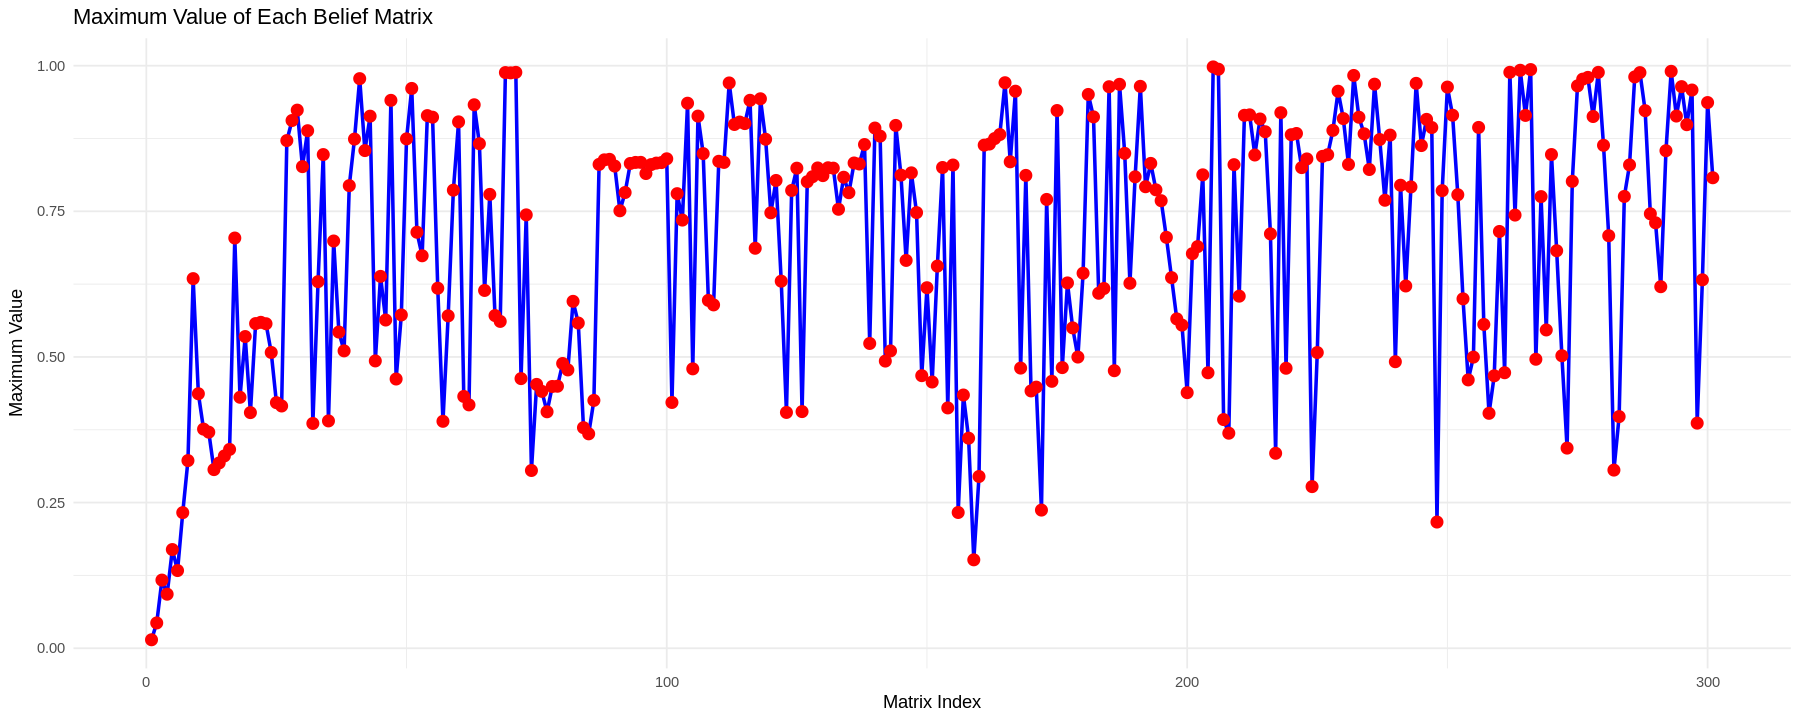

In [83]:
plot_belief_maxima(beliefs)

Overall accuracy: 23.59%


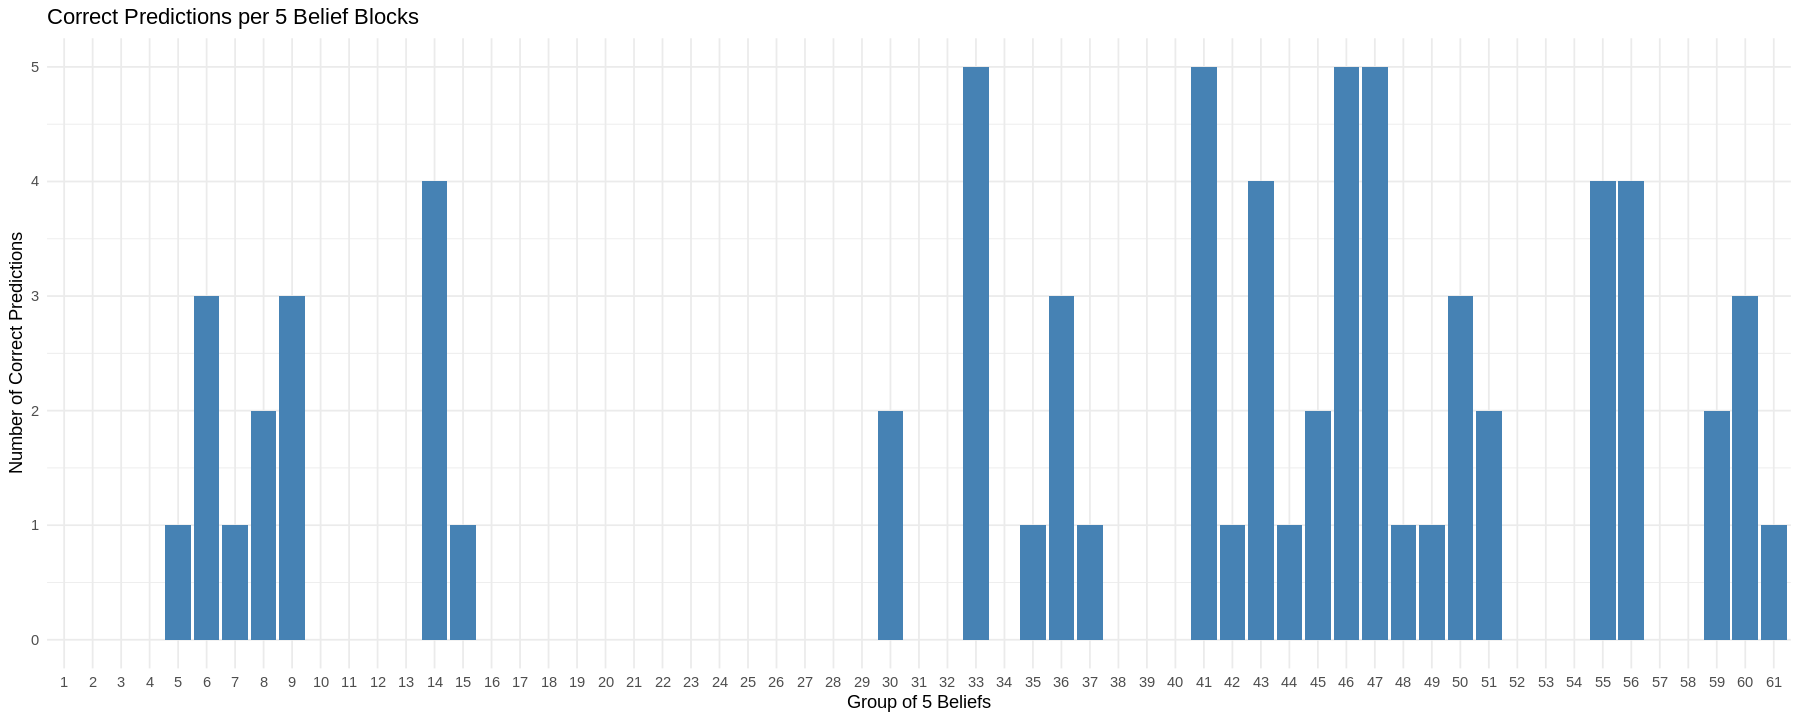

In [84]:
plot_belief_accuracy(beliefs, real_pos)

8.1. Change the model error percentage according to the table below and compare the graphs for 300 moves.
+ At each step, change the `SENSOR_ERROR` and `MOVE_ERROR` values ​​and call the `model` function again and plot the model output with given functions.

| Sensor error | Movement Error |
| ------------ | -------------- |
| 0.01         | 0.01           |
| 0.05         | 0.05           |
| 0.6          | 0.6            |
| 0.6          | 0.001          |
| 0.001        | 0.6            |

+ **Note:** Don't use `for` and plot each graph in a **separate cell**.

8.2. Finally, analyze the results and check the reason for the behavior of each chart. Also, compare the importance of sensor error and movement error according to the results.

Overall accuracy: 35.88%


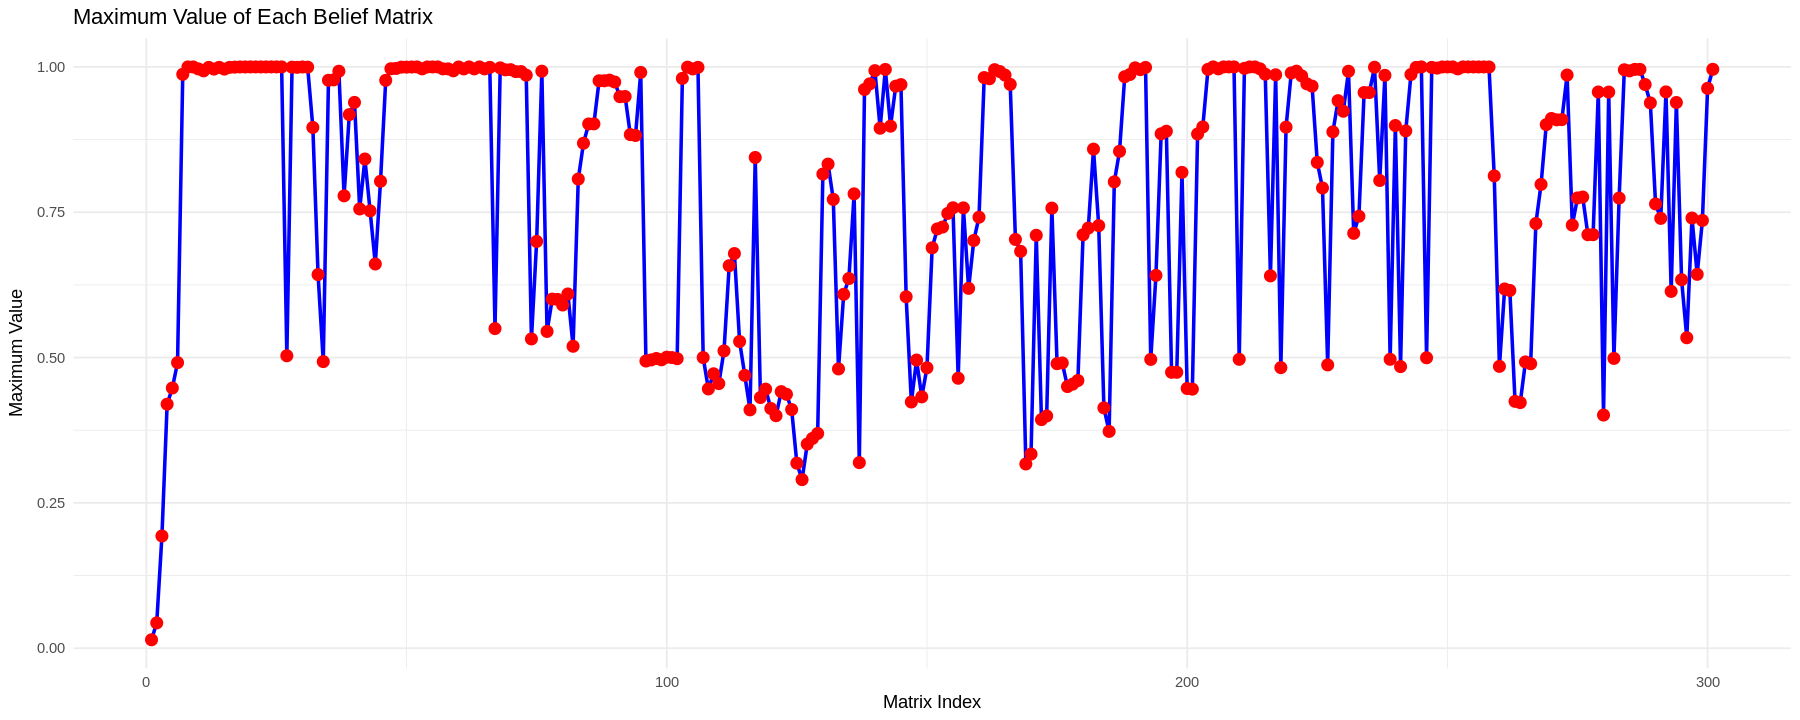

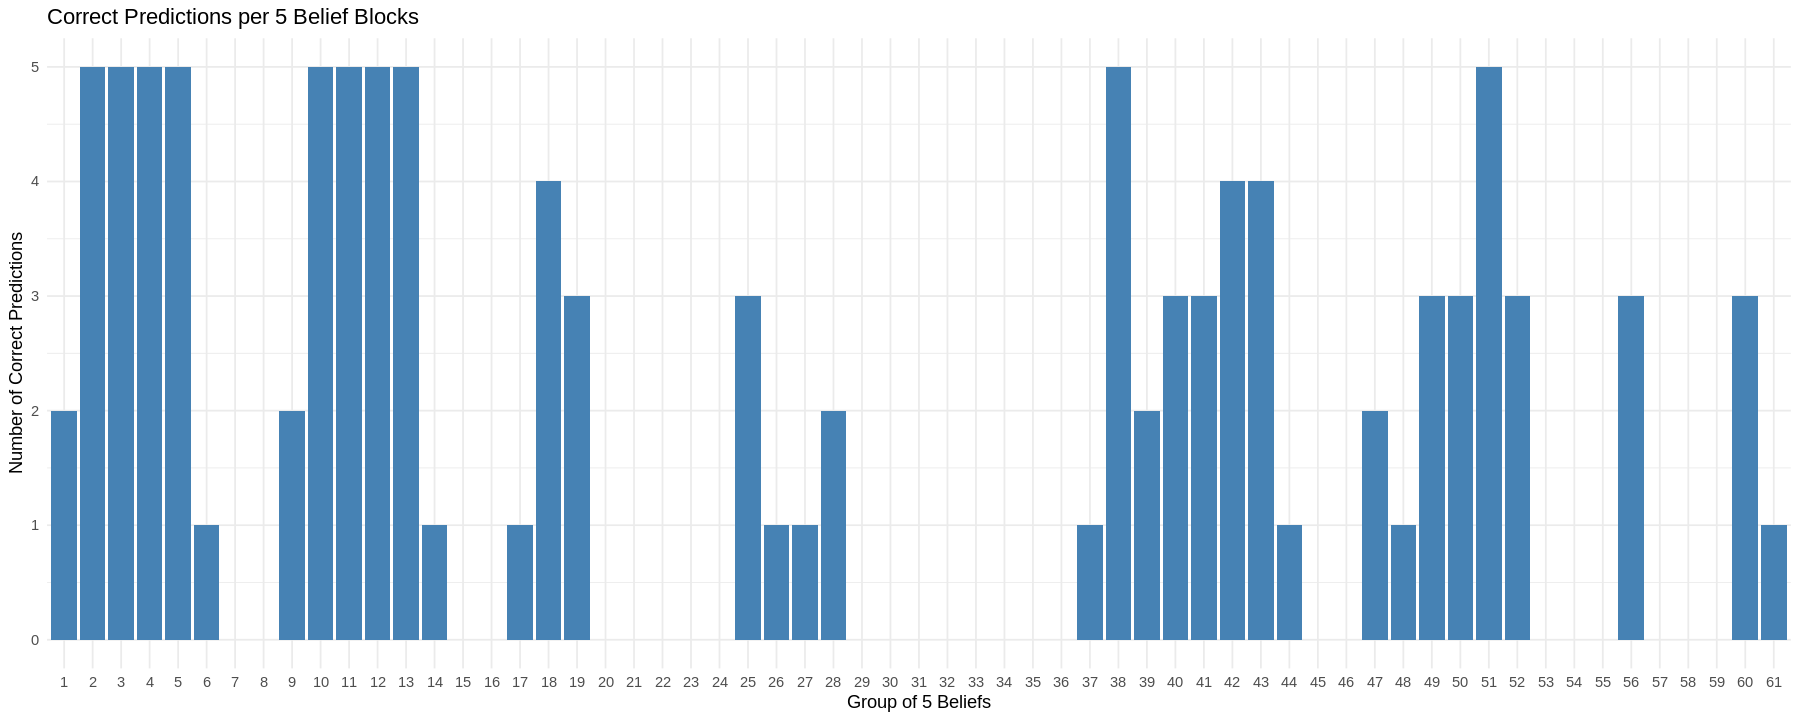

In [85]:
# --- Set errors ---
SENSOR_ERROR <- 0.01
MOVE_ERROR <- 0.01

# --- Run model ---
output <- model(map, chosen_dirs)

# --- Plot maximum likelihood belief ---
plot_belief_maxima(output$beliefs)

# --- Evaluate accuracy ---
plot_belief_accuracy(output$beliefs, output$real_pos)

Overall accuracy: 32.23%


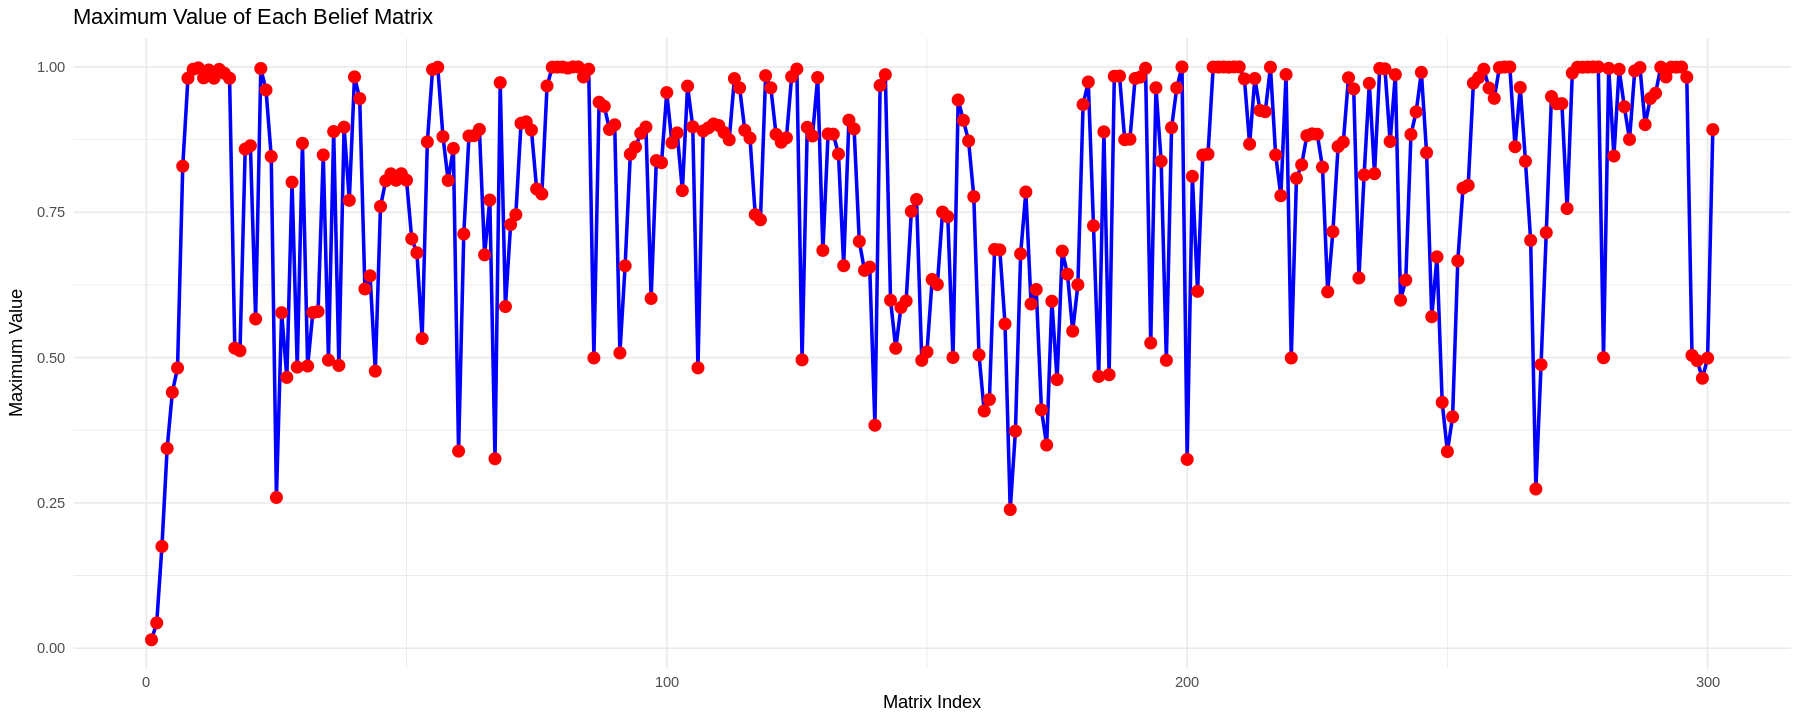

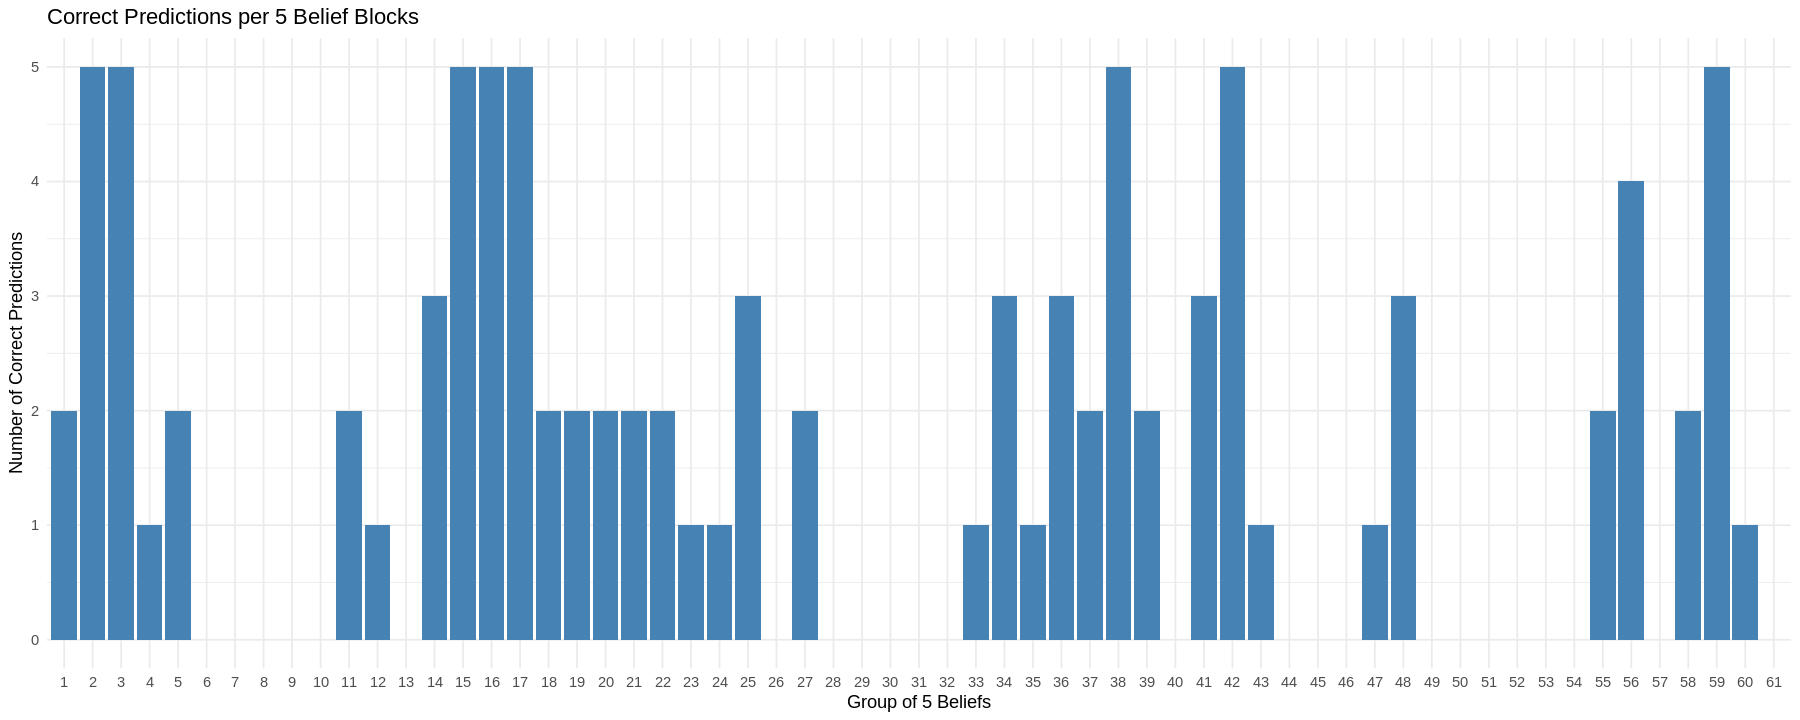

In [86]:
# --- Set errors ---
SENSOR_ERROR <- 0.05
MOVE_ERROR <- 0.05

# --- Run model ---
output <- model(map, chosen_dirs)

# --- Plot maximum likelihood belief ---
plot_belief_maxima(output$beliefs)

# --- Evaluate accuracy ---
plot_belief_accuracy(output$beliefs, output$real_pos)

Overall accuracy: 0.00%


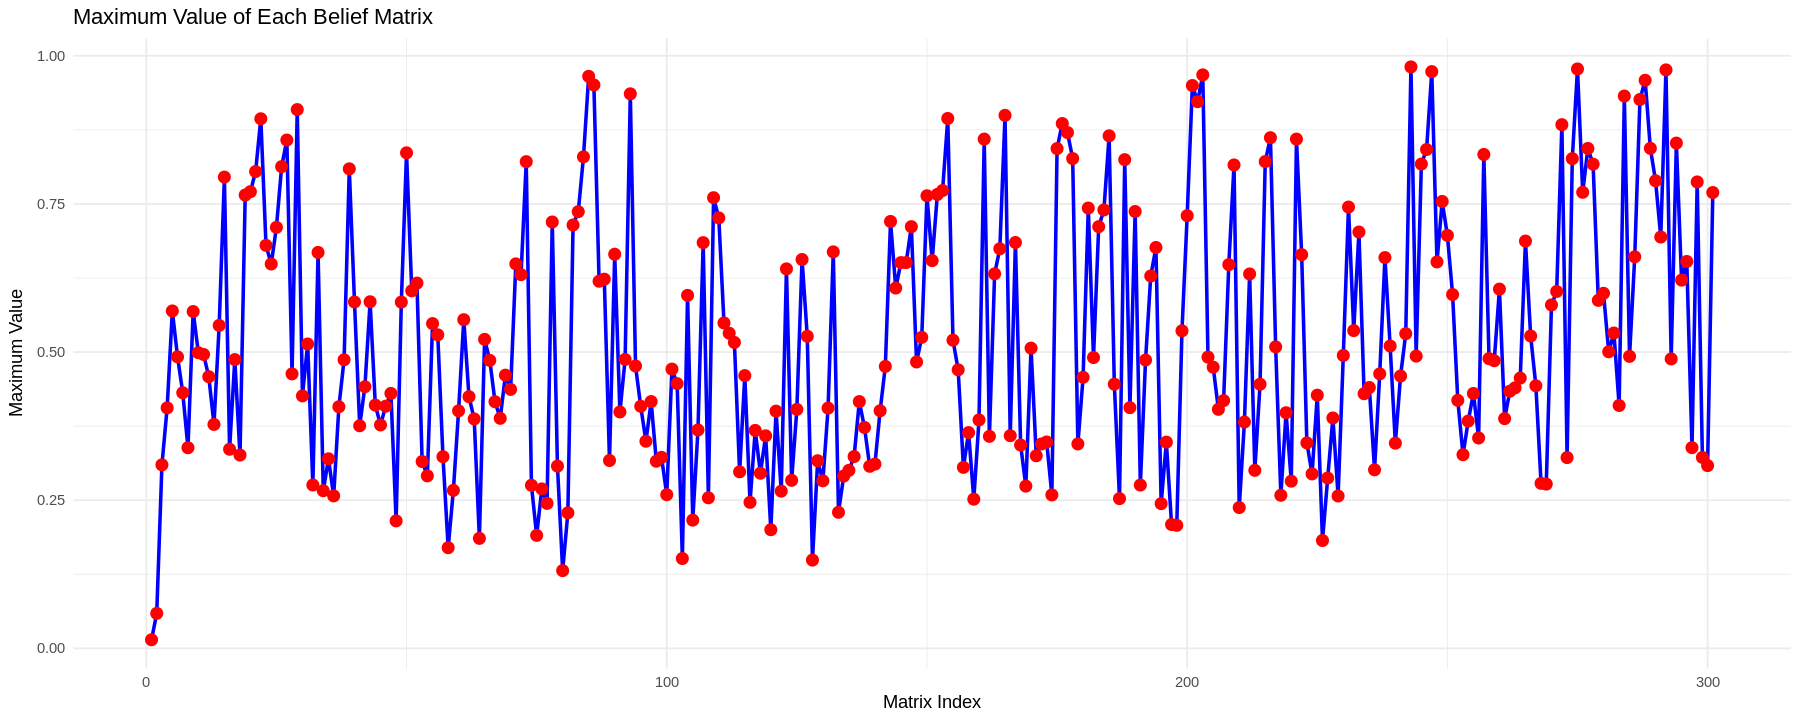

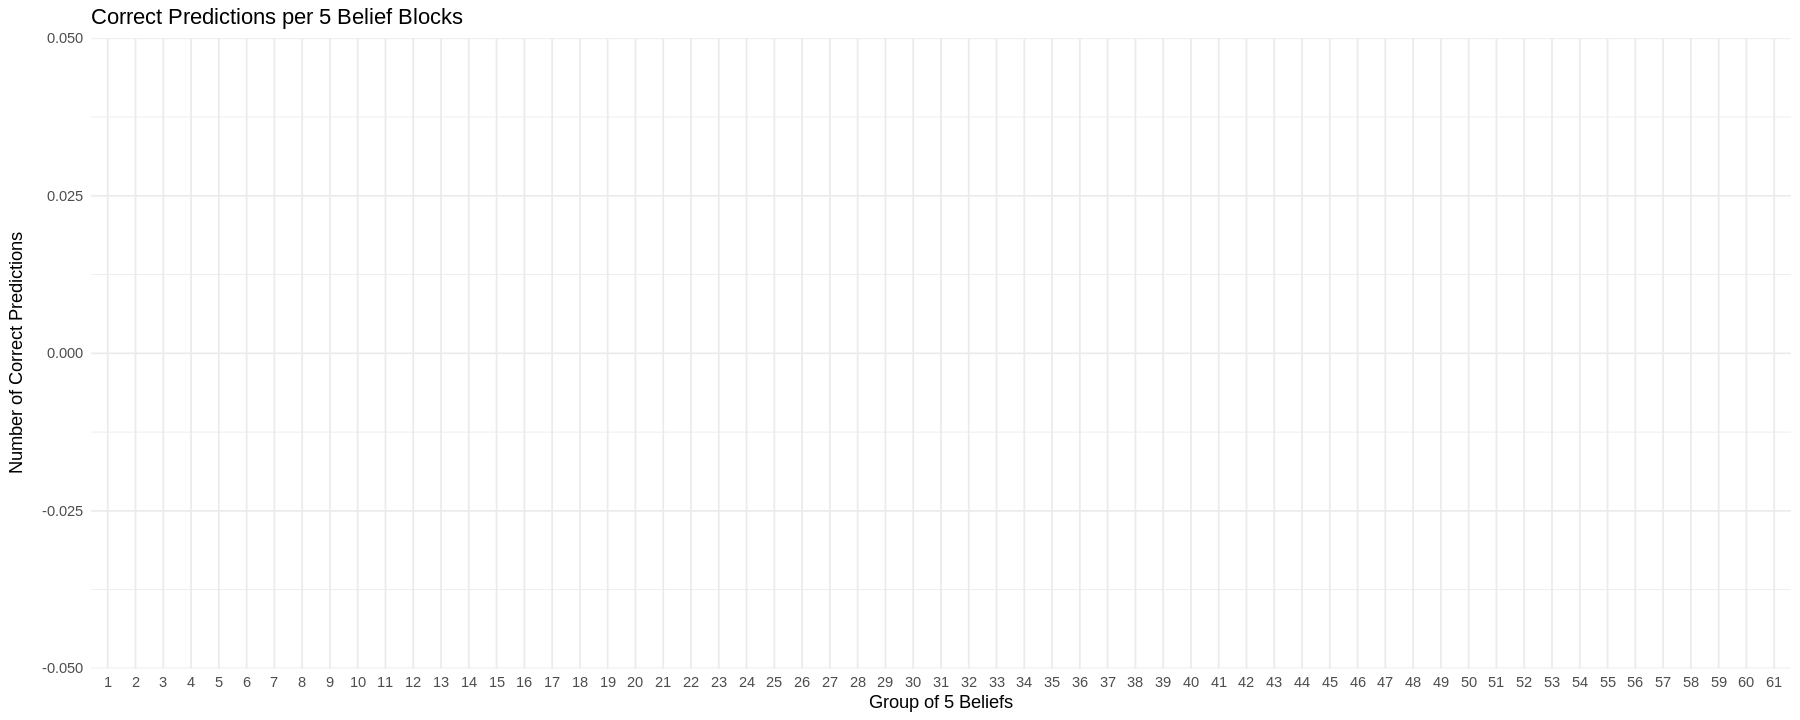

In [87]:
# --- Set errors ---
SENSOR_ERROR <- 0.6
MOVE_ERROR <- 0.6

# --- Run model ---
output <- model(map, chosen_dirs)

# --- Plot maximum likelihood belief ---
plot_belief_maxima(output$beliefs)

# --- Evaluate accuracy ---
plot_belief_accuracy(output$beliefs, output$real_pos)

Overall accuracy: 47.51%


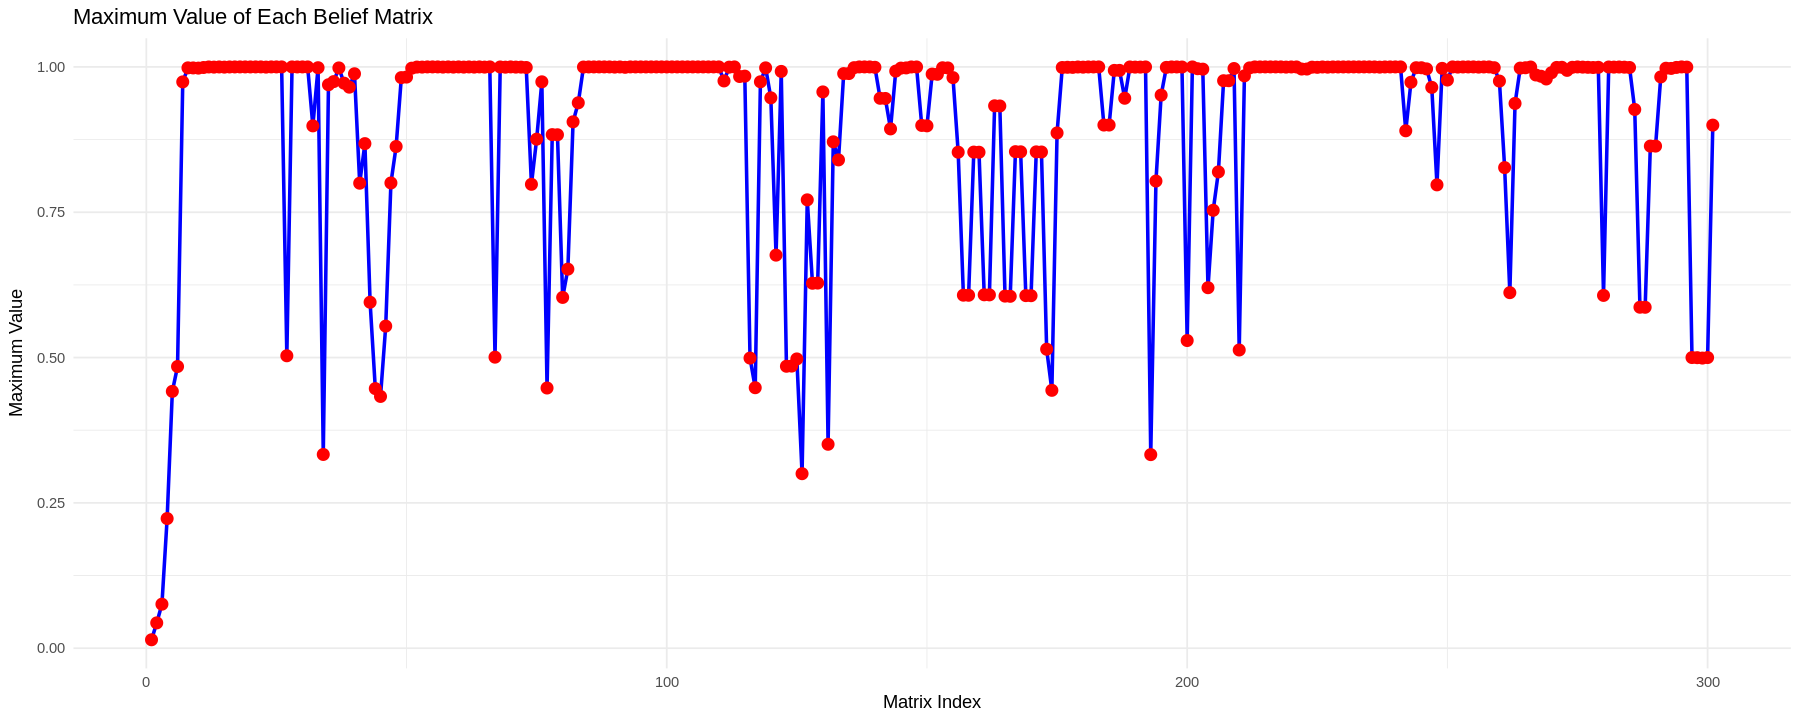

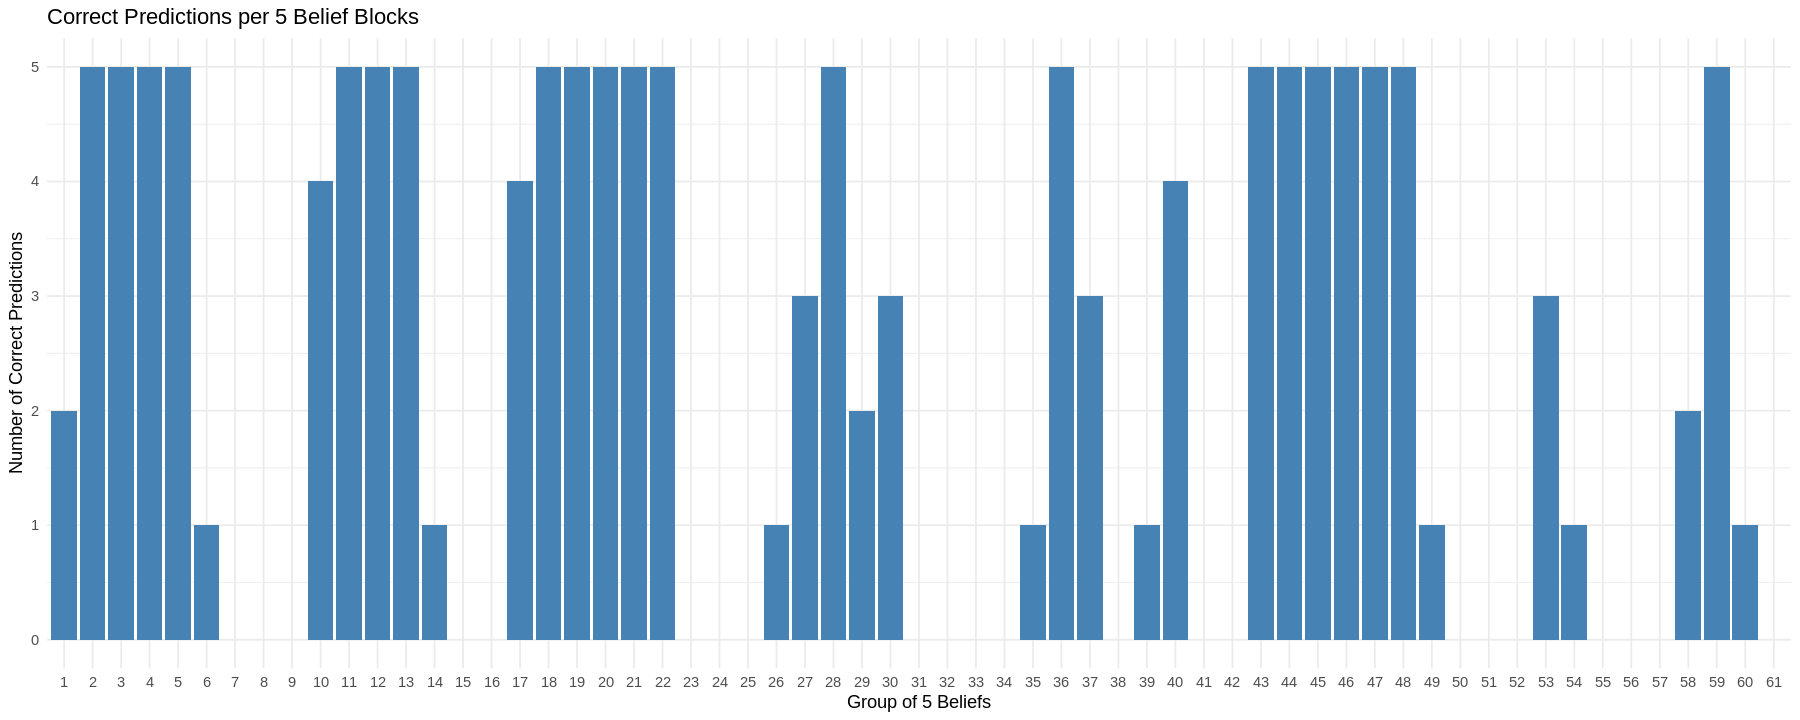

In [88]:
# --- Set errors ---
SENSOR_ERROR <- 0.06
MOVE_ERROR <- 0.001

# --- Run model ---
output <- model(map, chosen_dirs)

# --- Plot maximum likelihood belief ---
plot_belief_maxima(output$beliefs)

# --- Evaluate accuracy ---
plot_belief_accuracy(output$beliefs, output$real_pos)

Overall accuracy: 27.91%


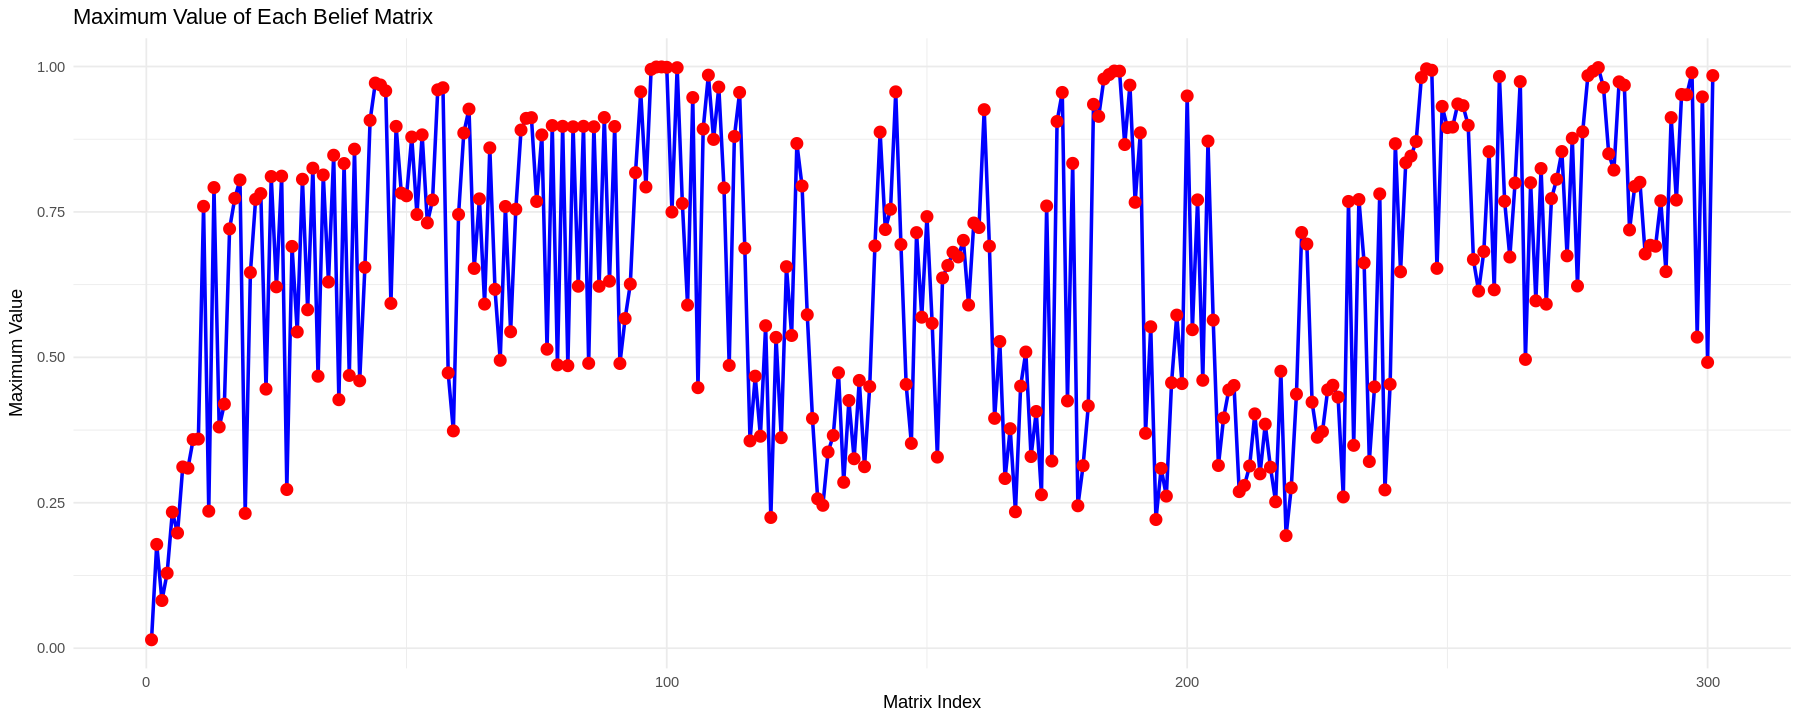

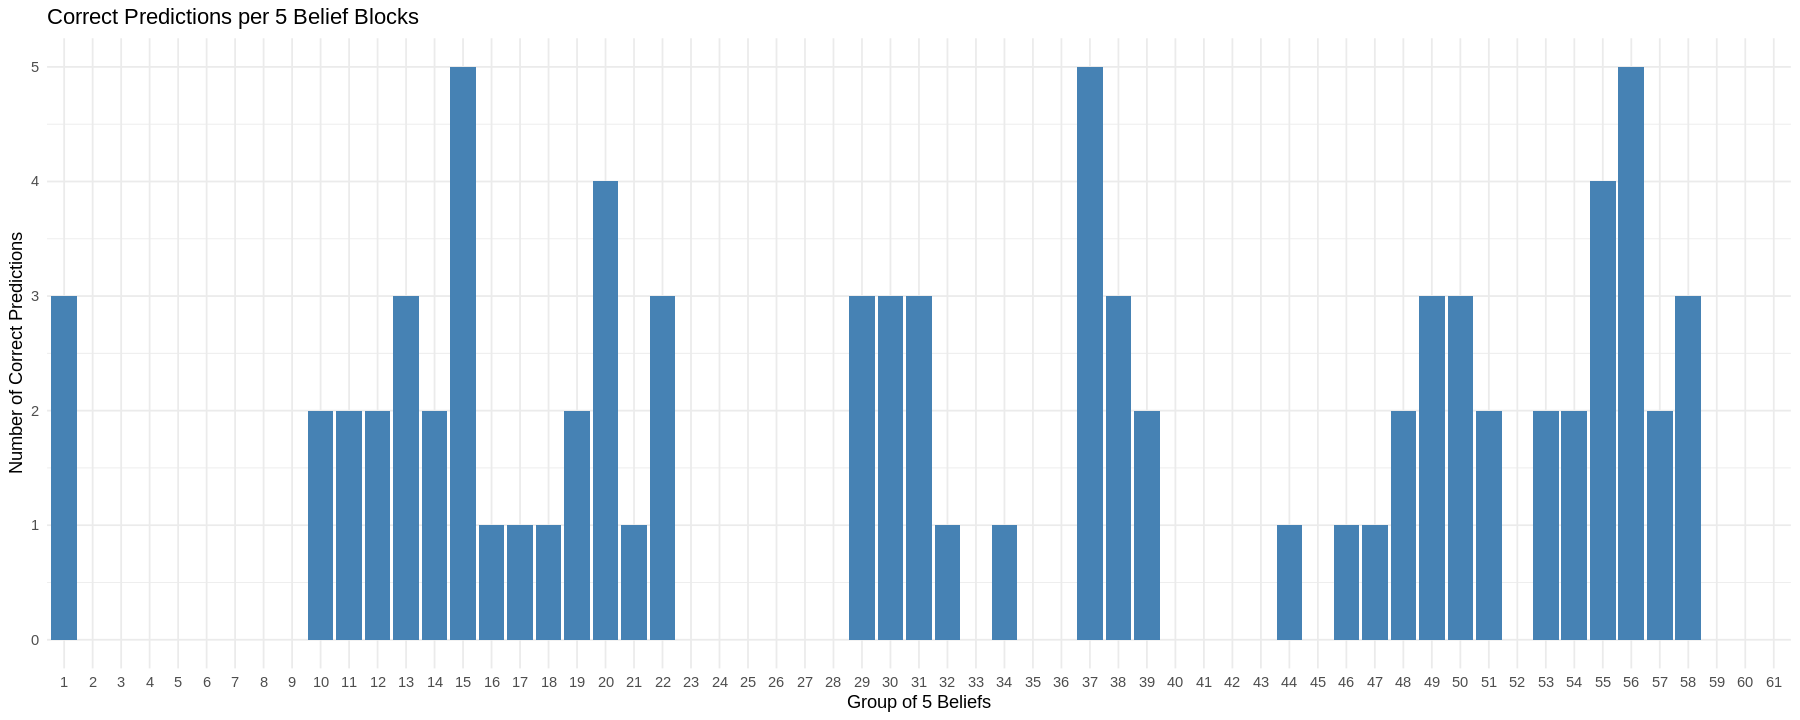

In [89]:
# --- Set errors ---
SENSOR_ERROR <- 0.001
MOVE_ERROR <- 0.6

# --- Run model ---
output <- model(map, chosen_dirs)

# --- Plot maximum likelihood belief ---
plot_belief_maxima(output$beliefs)

# --- Evaluate accuracy ---
plot_belief_accuracy(output$beliefs, output$real_pos)

🔴 **8.2 TO DO**